# WildBook – A Gemma 4-powered biodiversity co-pilot for camera traps

## Author: Nayananshu Garai

WildBook turns camera-trap detections into event-level biodiversity insights, anomaly alerts, and ranger-facing summaries using a three-layer pipeline: Perception, Analytics, and Gemma 4 reasoning.

## Exported Model

The fine‑tuned model and LoRA adapters are saved in `./WildBook‑Gemma`. You can load them with `FastLanguageModel.get_peft_model(...)` for inference.

## 1. Setup & Imports

This notebook is designed to run on Kaggle with the iWildCam2021 competition dataset. It automatically discovers the dataset under `/kaggle/input`, including the `metadata/` bundle, the `train/` and `test/` image folders, and auxiliary CSV files.


In [1]:
# Core libraries
import os
import json
import math
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Optional
import torch
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

COMPETITION_INPUT_ROOT = Path("/kaggle/input/competitions/iwildcam2021-fgvc8")
KAGGLE_INPUT_ROOT = Path("/kaggle/input")
LOCAL_FALLBACK_ROOT = Path("./iWildCard")
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def _discover_candidate_roots() -> List[Path]:
    candidates: List[Path] = []
    for root in [COMPETITION_INPUT_ROOT, KAGGLE_INPUT_ROOT, LOCAL_FALLBACK_ROOT]:
        if not root.exists():
            continue
        candidates.append(root)
        for child in sorted(root.iterdir()):
            if child.is_dir():
                candidates.append(child)
    return candidates


def discover_iwildcam_layout() -> Dict[str, Optional[Path]]:
    layout: Dict[str, Optional[Path]] = {
        "root": None,
        "competition_dir": None,
        "metadata_dir": None,
        "train_dir": None,
        "test_dir": None,
        "sample_submission": None,
    }

    for candidate in _discover_candidate_roots():
        files = {p.name.lower(): p for p in candidate.iterdir() if p.is_file()}
        dirs = {p.name.lower(): p for p in candidate.iterdir() if p.is_dir()}

        if "metadata" in dirs and layout["metadata_dir"] is None:
            layout["metadata_dir"] = dirs["metadata"]

        if "train" in dirs and layout["train_dir"] is None:
            layout["train_dir"] = dirs["train"]
        if "test" in dirs and layout["test_dir"] is None:
            layout["test_dir"] = dirs["test"]

        if "sample_submission.csv" in files and layout["sample_submission"] is None:
            layout["sample_submission"] = files["sample_submission.csv"]

        if layout["metadata_dir"] is not None and layout["root"] is None:
            layout["root"] = candidate
            break

    if layout["root"] is None and layout["metadata_dir"] is not None:
        layout["root"] = layout["metadata_dir"].parent

    return layout


DATA_LAYOUT = discover_iwildcam_layout()


def layout_summary(layout: Dict[str, Optional[Path]]) -> Dict[str, Optional[str]]:
    summary = {key: (str(value) if value is not None else None) for key, value in layout.items()}
    print("Detected iWildCam inputs:")
    for key, value in summary.items():
        print(f"- {key}: {value}")
    return summary


LAYOUT_SUMMARY = layout_summary(DATA_LAYOUT)

Detected iWildCam inputs:
- root: /kaggle/input/competitions/iwildcam2021-fgvc8
- competition_dir: None
- metadata_dir: /kaggle/input/competitions/iwildcam2021-fgvc8/metadata
- train_dir: /kaggle/input/competitions/iwildcam2021-fgvc8/train
- test_dir: /kaggle/input/competitions/iwildcam2021-fgvc8/test
- sample_submission: /kaggle/input/competitions/iwildcam2021-fgvc8/sample_submission.csv


In [2]:
import sys


# Check GPU availability
if torch.cuda.is_available():
    print(f"✓ GPU detected: {torch.cuda.get_device_name(0)}")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("⚠️ WARNING: No GPU detected. Training will be very slow.")
    print("Please ensure you are running on Kaggle with GPU enabled.")

# Memory optimization flags for T4
torch.cuda.empty_cache()
if hasattr(torch.cuda, 'set_per_process_memory_fraction'):
    torch.cuda.set_per_process_memory_fraction(0.95)  # Use 95% of GPU memory

print("\n" + "=" * 80 + "\n")

✓ GPU detected: Tesla T4
  CUDA Version: 12.8
  GPU Memory: 15.64 GB




## 2. Configuration

We work with a compact subset of camera-trap data to keep the prototype fast and reproducible.

In [3]:
@dataclass
class DatasetConfig:
    dataset_name: str = "snapshot_serengeti_subset"
    species_of_interest: Optional[List[str]] = None
    max_images_per_camera: int = 200
    event_window_minutes: int = 10
    random_seed: int = 42

config = DatasetConfig(
    species_of_interest=["wildebeest", "zebra", "elephant", "gazelle", "giraffe"]
)

np.random.seed(config.random_seed)

## 3. Data Loading

The notebook reads the iWildCam2021 competition bundle from the `metadata/` folder and any auxiliary CSV tables such as sequence count annotations.


In [4]:
def load_json_bundle(metadata_dir: Optional[Path]) -> Dict[str, object]:
    bundle: Dict[str, object] = {}
    if metadata_dir is None or not metadata_dir.exists():
        return bundle

    candidate_files = [
        "iwildcam2021_train_annotations.json",
        "iwildcam2021_test_information.json",
        "iwildcam2021_megadetector_results.json",
        "train_annotations.json",
        "test_information.json",
        "megadetector_results.json",
    ]
    for filename in candidate_files:
        path = metadata_dir / filename
        if path.exists():
            with open(path, "r", encoding="utf-8") as handle:
                bundle[path.stem] = json.load(handle)
    return bundle


def load_auxiliary_tables(metadata_dir: Optional[Path]) -> Dict[str, pd.DataFrame]:
    tables: Dict[str, pd.DataFrame] = {}
    if metadata_dir is None or not metadata_dir.exists():
        return tables

    for csv_path in sorted(metadata_dir.glob("*.csv")):
        try:
            tables[csv_path.name] = pd.read_csv(csv_path)
        except Exception:
            continue
    return tables


METADATA_BUNDLE = load_json_bundle(DATA_LAYOUT.get("metadata_dir"))
AUX_TABLES = load_auxiliary_tables(DATA_LAYOUT.get("metadata_dir"))
TRAIN_SEQUENCE_COUNTS = AUX_TABLES.get("train_sequence_counts.csv", pd.DataFrame())

print(f"Metadata JSON files loaded: {list(METADATA_BUNDLE.keys())}")
print(f"Auxiliary CSV files loaded: {list(AUX_TABLES.keys())}")


def build_source_frame(metadata_bundle: Dict[str, object]) -> pd.DataFrame:
    train_annotations = metadata_bundle.get("iwildcam2021_train_annotations")
    if isinstance(train_annotations, dict):
        images = pd.DataFrame(train_annotations.get("images", []))
        annotations = pd.DataFrame(train_annotations.get("annotations", []))
        if not images.empty and not annotations.empty and "id" in images.columns and "image_id" in annotations.columns:
            frame = images.merge(annotations, left_on="id", right_on="image_id", how="left")
            return frame
        if not images.empty:
            return images

    return pd.DataFrame()


metadata_df = build_source_frame(METADATA_BUNDLE)
metadata_df.head()

Metadata JSON files loaded: ['iwildcam2021_train_annotations', 'iwildcam2021_test_information', 'iwildcam2021_megadetector_results']
Auxiliary CSV files loaded: []


,seq_num_frames,location,datetime,id_x,seq_id,width,height,file_name,sub_location,seq_frame_num,id_y,image_id,category_id
0,6,3,2013-06-05 05:44:19.000,8b02698a-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8b02698a-21bc-11ea-a13a-137349068a90.jpg,0.0,0,9e8db252-21bc-11ea-a13a-137349068a90,8b02698a-21bc-11ea-a13a-137349068a90,380
1,6,3,2013-06-05 05:44:20.000,8e5b81de-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8e5b81de-21bc-11ea-a13a-137349068a90.jpg,0.0,1,a1a5e0ea-21bc-11ea-a13a-137349068a90,8e5b81de-21bc-11ea-a13a-137349068a90,380
2,6,3,2013-06-05 05:44:21.000,8c6be0e4-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8c6be0e4-21bc-11ea-a13a-137349068a90.jpg,0.0,2,9f580656-21bc-11ea-a13a-137349068a90,8c6be0e4-21bc-11ea-a13a-137349068a90,380
3,6,3,2013-06-05 05:44:22.000,8fdf7998-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8fdf7998-21bc-11ea-a13a-137349068a90.jpg,0.0,3,a20177d4-21bc-11ea-a13a-137349068a90,8fdf7998-21bc-11ea-a13a-137349068a90,380
4,6,3,2013-06-05 05:44:23.000,96093c50-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,96093c50-21bc-11ea-a13a-137349068a90.jpg,0.0,4,9f940ac0-21bc-11ea-a13a-137349068a90,96093c50-21bc-11ea-a13a-137349068a90,380


In [5]:
# Metadata sanity check and category mapping

CATEGORY_MAP = {}

train_meta = METADATA_BUNDLE.get("iwildcam2021_train_annotations")
if isinstance(train_meta, dict):
    images = train_meta.get("images", [])
    annotations = train_meta.get("annotations", [])
    categories = train_meta.get("categories", [])
    category_map = {}
    for cat in categories:
        cat_id = cat.get("id")
        cat_name = cat.get("name") or cat.get("common_name") or str(cat_id)
        if cat_id is not None:
            category_map[cat_id] = cat_name
    CATEGORY_MAP = category_map
    print("Train annotations summary:")
    print(f"- images: {len(images)}")
    print(f"- annotations: {len(annotations)}")
    print(f"- categories: {len(categories)}")
else:
    print("Train annotations not found in metadata bundle.")

test_meta = METADATA_BUNDLE.get("iwildcam2021_test_information")
if isinstance(test_meta, dict):
    test_images = test_meta.get("images", [])
    print("Test info summary:")
    print(f"- images: {len(test_images)}")

detector_meta = METADATA_BUNDLE.get("iwildcam2021_megadetector_results")
if isinstance(detector_meta, dict):
    detector_images = detector_meta.get("images", [])
    detector_annotations = detector_meta.get("annotations", [])
    if detector_annotations:
        detection_count = len(detector_annotations)
    else:
        detection_count = sum(
            len(image.get("detections", []))
            for image in detector_images
            if isinstance(image, dict)
        )
    if detection_count == 0:
        print("Warning: No detections found in Megadetector results.")
    print("Megadetector summary:")
    print(f"- images: {len(detector_images)}")
    print(f"- detections: {detection_count}")

if not CATEGORY_MAP:
    print("Note: CATEGORY_MAP is empty; species names will use category_id values.")

Train annotations summary:
- images: 203314
- annotations: 203314
- categories: 205
Test info summary:
- images: 60214
Megadetector summary:
- images: 263504
- detections: 295985


In [6]:
EXPECTED_COLUMNS = {
    "timestamp": ["timestamp", "start_time", "date_time", "datetime", "time"],
    "species": ["species", "category_name", "animal_type", "taxon", "label", "common_name"],
    "count": ["count", "number", "quantity", "animal_count", "num_animals"],
    "camera_id": ["camera_id", "camera", "trap_id", "location_id", "site_id", "location", "site"],
    "location": ["location", "site", "site_id", "region"],
    "seq_id": ["seq_id", "sequence_id", "sequence", "event_id"],
    "image_path": ["image_path", "file_name", "filepath", "path", "image", "img_path"],
}


def remap_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Remap arbitrary column names to the WildBook standard."""
    if df.empty:
        return df
    remapped = df.copy()
    for target, candidates in EXPECTED_COLUMNS.items():
        if target in remapped.columns:
            continue
        for col in candidates:
            if col in remapped.columns:
                remapped[target] = remapped[col]
                break
    return remapped


COLUMN_ALIASES = {
    "datetime": "timestamp",
    "date_time": "timestamp",
    "timestamp": "timestamp",
    "location": "camera_id",
    "site": "camera_id",
    "camera": "camera_id",
    "seq_id": "seq_id",
    "sequence_id": "seq_id",
    "file_name": "image_path",
    "filepath": "image_path",
    "path": "image_path",
    "category_name": "species",
    "common_name": "species",
    "label": "species",
    "animal": "species",
    "count": "count",
    "num_animals": "count",
    "animal_count": "count",
}


def normalize_metadata(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df

    df = remap_columns(df)
    rename_map = {
        source_name: target_name
        for source_name, target_name in COLUMN_ALIASES.items()
        if source_name in df.columns and target_name not in df.columns
    }
    if rename_map:
        df = df.rename(columns=rename_map)

    if "timestamp" in df.columns:
        df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

    if "camera_id" not in df.columns:
        if "location" in df.columns:
            df["camera_id"] = df["location"].astype(str)
        else:
            df["camera_id"] = "camera_unknown"

    if "seq_id" not in df.columns:
        if "sequence" in df.columns:
            df["seq_id"] = df["sequence"].astype(str)
        elif "event_id" in df.columns:
            df["seq_id"] = df["event_id"].astype(str)

    if "count" in df.columns:
        df["count"] = pd.to_numeric(df["count"], errors="coerce").fillna(1).astype(int)
    else:
        df["count"] = 1

    if "species" not in df.columns:
        if "category_id" in df.columns:
            df["species"] = df["category_id"].astype(str)
        else:
            df["species"] = "animal"

    if "category_id" in df.columns and CATEGORY_MAP:
        mapped_species = df["category_id"].map(CATEGORY_MAP)
        df["species"] = mapped_species.fillna(df["species"].astype(str))

    if "image_path" not in df.columns:
        for fallback in ["file_name", "filename", "image", "img_path"]:
            if fallback in df.columns:
                df["image_path"] = df[fallback].astype(str)
                break

    if "season" not in df.columns:
        df["season"] = None

    return df


metadata_df = normalize_metadata(metadata_df)
metadata_df.head()

,seq_num_frames,location,datetime,id_x,seq_id,width,height,file_name,sub_location,seq_frame_num,id_y,image_id,category_id,timestamp,camera_id,image_path,count,species,season
0,6,3,2013-06-05 05:44:19.000,8b02698a-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8b02698a-21bc-11ea-a13a-137349068a90.jpg,0.0,0,9e8db252-21bc-11ea-a13a-137349068a90,8b02698a-21bc-11ea-a13a-137349068a90,380,2013-06-05 05:44:19,3,8b02698a-21bc-11ea-a13a-137349068a90.jpg,1,mazama temama,None
1,6,3,2013-06-05 05:44:20.000,8e5b81de-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8e5b81de-21bc-11ea-a13a-137349068a90.jpg,0.0,1,a1a5e0ea-21bc-11ea-a13a-137349068a90,8e5b81de-21bc-11ea-a13a-137349068a90,380,2013-06-05 05:44:20,3,8e5b81de-21bc-11ea-a13a-137349068a90.jpg,1,mazama temama,None
2,6,3,2013-06-05 05:44:21.000,8c6be0e4-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8c6be0e4-21bc-11ea-a13a-137349068a90.jpg,0.0,2,9f580656-21bc-11ea-a13a-137349068a90,8c6be0e4-21bc-11ea-a13a-137349068a90,380,2013-06-05 05:44:21,3,8c6be0e4-21bc-11ea-a13a-137349068a90.jpg,1,mazama temama,None
3,6,3,2013-06-05 05:44:22.000,8fdf7998-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,8fdf7998-21bc-11ea-a13a-137349068a90.jpg,0.0,3,a20177d4-21bc-11ea-a13a-137349068a90,8fdf7998-21bc-11ea-a13a-137349068a90,380,2013-06-05 05:44:22,3,8fdf7998-21bc-11ea-a13a-137349068a90.jpg,1,mazama temama,None
4,6,3,2013-06-05 05:44:23.000,96093c50-21bc-11ea-a13a-137349068a90,30048d32-7d42-11eb-8fb5-0242ac1c0002,1920,1080,96093c50-21bc-11ea-a13a-137349068a90.jpg,0.0,4,9f940ac0-21bc-11ea-a13a-137349068a90,96093c50-21bc-11ea-a13a-137349068a90,380,2013-06-05 05:44:23,3,96093c50-21bc-11ea-a13a-137349068a90.jpg,1,mazama temama,None


## 4. Event Construction

We group detections into short time windows per camera to build event-level records.

### Data Integrity Audit

This cell checks for missing critical metadata fields (season, seq_id, camera_id) and fills sensible defaults.

In [7]:
# Integrity audit and fill missing metadata values
if "season" in metadata_df.columns:
    missing_season = metadata_df["season"].isna().sum()
    if missing_season > 0:
        print(f"Season column has {missing_season} missing values; filling with 'unknown'.")
        metadata_df["season"] = metadata_df["season"].fillna("unknown")
else:
    print("Season column not present; adding with default 'unknown'.")
    metadata_df["season"] = "unknown"

if "seq_id" in metadata_df.columns:
    missing_seq = metadata_df["seq_id"].isna().sum()
    if missing_seq > 0:
        print(f"Seq_id column has {missing_seq} missing values; filling with placeholder.")
        metadata_df["seq_id"] = metadata_df["seq_id"].fillna("unknown_seq")
else:
    print("Seq_id column not present; adding placeholder.")
    metadata_df["seq_id"] = "unknown_seq"

if "camera_id" in metadata_df.columns:
    missing_cam = metadata_df["camera_id"].isna().sum()
    if missing_cam > 0:
        print(f"Camera_id column has {missing_cam} missing values; filling with 'camera_unknown'.")
        metadata_df["camera_id"] = metadata_df["camera_id"].fillna("camera_unknown")
else:
    print("Camera_id column not present; adding placeholder.")
    metadata_df["camera_id"] = "camera_unknown"

Season column has 203314 missing values; filling with 'unknown'.


In [8]:
def build_event_records(metadata: pd.DataFrame, window_minutes: int = 10) -> pd.DataFrame:
    if metadata.empty:
        return pd.DataFrame(
            columns=[
                "event_id", "camera_id", "seq_id", "start_time", "end_time", "species_list",
                "species_counts", "total_animals", "sample_image_path", "season"
            ]
        )

    df = metadata.copy()
    df = df.sort_values([c for c in ["camera_id", "timestamp", "seq_id"] if c in df.columns])

    if "seq_id" in df.columns and df["seq_id"].notna().any():
        grouping_columns = ["seq_id"]
    elif "camera_id" in df.columns and "timestamp" in df.columns:
        df["event_window"] = df["timestamp"].dt.floor(f"{window_minutes}min")
        grouping_columns = ["camera_id", "event_window"]
    elif "camera_id" in df.columns:
        grouping_columns = ["camera_id"]
    else:
        df["group_id"] = np.arange(len(df))
        grouping_columns = ["group_id"]

    records = []
    for group_key, group in df.groupby(grouping_columns):
        if isinstance(group_key, tuple):
            group_key = "_".join(str(part) for part in group_key)
        else:
            group_key = str(group_key)

        species_counts: Dict[str, int] = {}
        if "species" in group.columns:
            species_counts = group.groupby("species")["count"].sum().to_dict()
        elif "category_name" in group.columns:
            species_counts = group.groupby("category_name")["count"].sum().to_dict()
        elif "category_id" in group.columns:
            species_counts = group.groupby("category_id").size().to_dict()
        elif "count" in group.columns:
            species_counts = {"animal": int(group["count"].sum())}

        species_list = sorted(str(species) for species in species_counts.keys())
        total_animals = int(group["count"].sum()) if "count" in group.columns else len(group)
        sample_image_path = None
        for image_column in ["image_path", "file_name", "image", "filepath"]:
            if image_column in group.columns:
                sample_image_path = group[image_column].dropna().astype(str).iloc[0] if not group[image_column].dropna().empty else None
                break

        camera_id = group["camera_id"].iloc[0] if "camera_id" in group.columns else "camera_unknown"
        seq_id = group["seq_id"].iloc[0] if "seq_id" in group.columns else None
        if "start_time" in group.columns:
            start_time = group["start_time"].iloc[0]
        else:
            start_time = group["timestamp"].min() if "timestamp" in group.columns else None
        end_time = group["timestamp"].max() if "timestamp" in group.columns else start_time

        records.append(
            {
                "event_id": seq_id if seq_id not in [None, "", "nan"] else f"{camera_id}_{group_key}",
                "camera_id": camera_id,
                "seq_id": seq_id,
                "start_time": start_time,
                "end_time": end_time,
                "species_list": species_list,
                "species_counts": species_counts,
                "total_animals": total_animals,
                "sample_image_path": sample_image_path,
                "season": group["season"].iloc[0] if "season" in group.columns and not group["season"].isna().all() else None,
            }
        )

    return pd.DataFrame(records)


events_df = build_event_records(metadata_df, window_minutes=config.event_window_minutes)
events_df.head()


,event_id,camera_id,seq_id,start_time,end_time,species_list,species_counts,total_animals,sample_image_path,season
0,2ffd1232-7d42-11eb-8fb5-0242ac1c0002,324,2ffd1232-7d42-11eb-8fb5-0242ac1c0002,2013-02-12 07:43:33,2013-02-12 07:45:29,"[empty, macaca sp]","{'empty': 7, 'macaca sp': 3}",10,8c04dcaa-21bc-11ea-a13a-137349068a90.jpg,unknown
1,2ffd1584-7d42-11eb-8fb5-0242ac1c0002,324,2ffd1584-7d42-11eb-8fb5-0242ac1c0002,2013-02-12 07:45:36,2013-02-12 07:46:25,[empty],{'empty': 5},5,98a8112a-21bc-11ea-a13a-137349068a90.jpg,unknown
2,2ffd180e-7d42-11eb-8fb5-0242ac1c0002,271,2ffd180e-7d42-11eb-8fb5-0242ac1c0002,2013-03-20 12:52:58,2013-03-20 12:55:00,[empty],{'empty': 10},10,8b06c6d8-21bc-11ea-a13a-137349068a90.jpg,unknown
3,2ffd1926-7d42-11eb-8fb5-0242ac1c0002,271,2ffd1926-7d42-11eb-8fb5-0242ac1c0002,2013-03-20 12:55:05,2013-03-20 12:57:11,[empty],{'empty': 10},10,9505cd78-21bc-11ea-a13a-137349068a90.jpg,unknown
4,2ffd1a20-7d42-11eb-8fb5-0242ac1c0002,271,2ffd1a20-7d42-11eb-8fb5-0242ac1c0002,2013-03-20 12:57:17,2013-03-20 12:59:40,[empty],{'empty': 10},10,93ee9b36-21bc-11ea-a13a-137349068a90.jpg,unknown


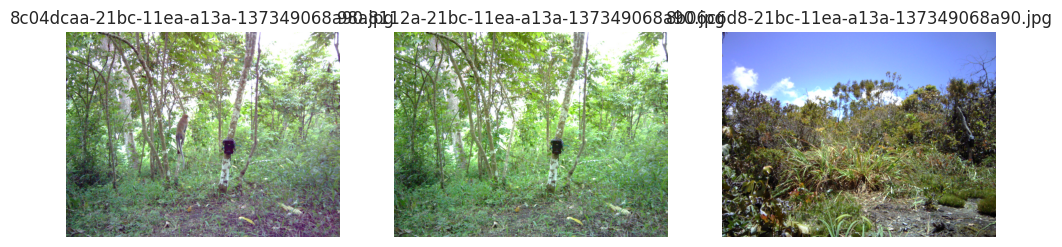

In [9]:


def resolve_image_path(filename: Optional[str]) -> Optional[Path]:
    if not filename:
        return None
    for base in [DATA_LAYOUT.get("train_dir"), DATA_LAYOUT.get("test_dir")]:
        if base is None:
            continue
        candidate = base / filename
        if candidate.exists():
            return candidate
    return None

if not events_df.empty:
    events_df["sample_image_resolved"] = events_df["sample_image_path"].apply(
        lambda x: str(resolve_image_path(x)) if resolve_image_path(x) else None
    )
    sample_paths = events_df["sample_image_resolved"].dropna().head(3).tolist()
    if sample_paths:
        try:
            from PIL import Image

            fig, axes = plt.subplots(1, len(sample_paths), figsize=(4 * len(sample_paths), 4))
            if len(sample_paths) == 1:
                axes = [axes]
            for ax, path in zip(axes, sample_paths):
                ax.imshow(Image.open(path))
                ax.set_title(Path(path).name)
                ax.axis("off")
            plt.show()
        except Exception as e:
            print(f"Sample image preview skipped: {e}")

In [10]:
events_csv = OUTPUT_DIR / "events.csv"
events_df.to_csv(events_csv, index=False)
events_csv

PosixPath('outputs/events.csv')

## 5. Feature Engineering

We compute aggregation features that help identify unusual group behavior or rare events.

In [11]:
def parse_species_counts(value):
    if isinstance(value, dict):
        return value
    if pd.isna(value):
        return {}
    if isinstance(value, str):
        try:
            return json.loads(value.replace("'", '"'))
        except Exception:
            return {}
    return {}

def compute_features(events: pd.DataFrame) -> pd.DataFrame:
    if events.empty:
        return pd.DataFrame()

    df = events.copy()
    df["species_counts_parsed"] = df["species_counts"].apply(parse_species_counts)

    # Ensure proper data types to prevent .mean() errors
    df["species_richness"] = df["species_counts_parsed"].apply(lambda d: int(len(d)))
    df["dominant_species"] = df["species_counts_parsed"].apply(
        lambda d: max(d, key=d.get) if d else None
    )
    df["dominant_count"] = df["species_counts_parsed"].apply(
        lambda d: int(max(d.values())) if d else 0
    )
    df["dominance_ratio"] = df.apply(
        lambda row: float((row["dominant_count"] / row["total_animals"])) if row["total_animals"] > 0 else 0.0,
        axis=1
    )

    # Species rarity score (higher = rarer composition)
    species_tally = {}
    for counts in df["species_counts_parsed"]:
        for species, count in counts.items():
            species_tally[species] = species_tally.get(species, 0.0) + float(count)
    total_species = float(sum(species_tally.values())) or 1.0
    species_freq = {species: count / total_species for species, count in species_tally.items()}
    df["species_rarity_score"] = df["species_counts_parsed"].apply(
        lambda d: float(sum(-np.log(species_freq.get(species, 1e-6)) * float(count) for species, count in d.items()))
    )

    # Lightweight temporal change proxy: compare against previous event at same camera.
    df = df.sort_values(["camera_id", "start_time"])
    df["prev_total_animals"] = df.groupby("camera_id")["total_animals"].shift(1).fillna(0).astype(int)
    df["temporal_change"] = (df["total_animals"] - df["prev_total_animals"]).astype(int)

    # Seasonal deviation (camera-specific baseline)
    if "season" in df.columns:
        df["season"] = df["season"].fillna("unknown")
        df["camera_season_median"] = df.groupby(["camera_id", "season"])[
            "total_animals"
        ].transform("median")
        df["seasonal_dev"] = (df["total_animals"] - df["camera_season_median"]).astype(float)
        df["seasonal_dev"] = df["seasonal_dev"].fillna(0.0)
    else:
        df["seasonal_dev"] = 0.0

    # Optional density proxy if bounding boxes or track distances are available.
    df["density_proxy"] = np.where(df["total_animals"] > 0, df["total_animals"], 0).astype(float)

    return df

feature_df = compute_features(events_df)
feature_df.head()

,event_id,camera_id,seq_id,start_time,end_time,species_list,species_counts,total_animals,sample_image_path,season,...,species_richness,dominant_species,dominant_count,dominance_ratio,species_rarity_score,prev_total_animals,temporal_change,camera_season_median,seasonal_dev,density_proxy
30248,975e82fe-21bc-11ea-a13a-137349068a90,0,975e82fe-21bc-11ea-a13a-137349068a90,2014-06-09 09:32:03,2014-06-09 09:32:03,[empty],{'empty': 3},3,87d70644-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1,empty,3,1.0,3.220836,0,3,3.0,0.0,3.0
14286,302f1138-7d42-11eb-8fb5-0242ac1c0002,1,302f1138-7d42-11eb-8fb5-0242ac1c0002,2013-01-17 13:05:21,2013-01-17 13:06:33,[equus grevyi],{'equus grevyi': 10},10,985f8e6e-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1,equus grevyi,10,1.0,53.702643,0,10,3.0,7.0,10.0
14287,302f11ba-7d42-11eb-8fb5-0242ac1c0002,1,302f11ba-7d42-11eb-8fb5-0242ac1c0002,2013-01-17 13:06:34,2013-01-17 13:07:11,[equus grevyi],{'equus grevyi': 8},8,8efbfc18-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1,equus grevyi,8,1.0,42.962114,10,-2,3.0,5.0,8.0
30344,9766b186-21bc-11ea-a13a-137349068a90,1,9766b186-21bc-11ea-a13a-137349068a90,2013-01-17 21:00:48,2013-01-17 21:00:48,[empty],{'empty': 1},1,8704e542-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1,empty,1,1.0,1.073612,8,-7,3.0,-2.0,1.0
23989,94471b3a-21bc-11ea-a13a-137349068a90,1,94471b3a-21bc-11ea-a13a-137349068a90,2013-01-18 09:20:56,2013-01-18 09:20:58,[empty],{'empty': 3},3,944719b4-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1,empty,3,1.0,3.220836,1,2,3.0,0.0,3.0


In [12]:
numeric_cols = [
    "total_animals",
    "species_richness",
    "dominant_count",
    "dominance_ratio",
    "species_rarity_score",
    "prev_total_animals",
    "temporal_change",
    "seasonal_dev",
    "density_proxy",
]

print("=" * 80)
print("DATA VALIDATION REPORT")
print("=" * 80)

# Verify all numeric columns exist
print("\n1. Checking numeric columns...")
missing_cols = [col for col in numeric_cols if col not in feature_df.columns]
if missing_cols:
    print(f"  WARNING: Missing columns: {missing_cols}")
else:
    print(f"  All {len(numeric_cols)} numeric columns present")

# Verify data types
print("\n2. Checking data types...")
for col in numeric_cols:
    if col in feature_df.columns:
        dtype = feature_df[col].dtype
        if pd.api.types.is_numeric_dtype(feature_df[col]):
            print(f"  {col}: {dtype} (numeric)")
        else:
            print(f"  {col}: {dtype} (NOT numeric - may cause errors)")

# Verify no NaN or inf values in critical columns
print("\n3. Checking for NaN/inf values...")
for col in numeric_cols:
    if col in feature_df.columns:
        nan_count = feature_df[col].isna().sum()
        inf_count = np.isinf(feature_df[col]).sum()
        if nan_count > 0 or inf_count > 0:
            print(f"  {col}: {nan_count} NaN, {inf_count} inf")
        else:
            print(f"  {col}: No NaN/inf")

# Verify can call .describe() without error
print("\n4. Testing aggregation functions...")
try:
    stats = feature_df[numeric_cols].describe(include="all")
    print("  .describe() successful")
    print("\nStatistics:")
    print(stats)
except Exception as e:
    print(f"  Error calling .describe(): {e}")
    print("  This may cause problems in anomaly detection.")

# Verify row count
print(f"\n5. Data shape: {feature_df.shape[0]} rows, {feature_df.shape[1]} columns")
if feature_df.shape[0] < 2:
    print("  WARNING: Less than 2 rows - anomaly detection may fail")
else:
    print("  Sufficient data for anomaly detection")



DATA VALIDATION REPORT

1. Checking numeric columns...
  All 9 numeric columns present

2. Checking data types...
  total_animals: int64 (numeric)
  species_richness: int64 (numeric)
  dominant_count: int64 (numeric)
  dominance_ratio: float64 (numeric)
  species_rarity_score: float64 (numeric)
  prev_total_animals: int64 (numeric)
  temporal_change: int64 (numeric)
  seasonal_dev: float64 (numeric)
  density_proxy: float64 (numeric)

3. Checking for NaN/inf values...
  total_animals: No NaN/inf
  species_richness: No NaN/inf
  dominant_count: No NaN/inf
  dominance_ratio: No NaN/inf
  species_rarity_score: No NaN/inf
  prev_total_animals: No NaN/inf
  temporal_change: No NaN/inf
  seasonal_dev: No NaN/inf
  density_proxy: No NaN/inf

4. Testing aggregation functions...
  .describe() successful

Statistics:
       total_animals  species_richness  dominant_count  dominance_ratio  \
count   36547.000000      36547.000000    36547.000000     36547.000000   
mean        5.563083          1

## 6. Anomaly Detection

We use simple unsupervised methods to rank unusual events. These scores are used for prioritization, not as ground truth.

In [13]:
def fit_anomaly_model(feature_df: pd.DataFrame):
    if feature_df.empty:
        return None, feature_df

    df = feature_df.copy()
    
    # Ensure all numeric columns exist and have proper types
    for col in numeric_cols:
        if col not in df.columns:
            df[col] = 0.0
        # Convert to float to prevent dtype issues
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    
    model_input = df[numeric_cols].fillna(0.0).astype(float)
    
    # Verify we have valid numeric data before training
    if model_input.empty or model_input.shape[0] < 2:
        print("Warning: Not enough data for anomaly detection. Using default scores.")
        df["anomaly_score"] = 0.0
        df["anomaly_threshold"] = 0.0
        df["is_anomaly"] = False
        return None, df

    try:
        model = IsolationForest(
            n_estimators=100,  # Reduced from 200 for Kaggle T4 memory efficiency
            contamination=0.1,
            random_state=config.random_seed,
            n_jobs=1  # Kaggle T4 single-threaded safe
        )
        model.fit(model_input)

        df["anomaly_score"] = -model.decision_function(model_input)
        anomaly_threshold = float(df["anomaly_score"].quantile(0.90))
        df["anomaly_threshold"] = anomaly_threshold
        df["is_anomaly"] = df["anomaly_score"] >= anomaly_threshold
    except Exception as e:
        print(f"Warning: Anomaly detection failed: {e}")
        df["anomaly_score"] = 0.0
        df["anomaly_threshold"] = 0.0
        df["is_anomaly"] = False
        return None, df

    return model, df

anomaly_model, scored_df = fit_anomaly_model(feature_df)
scored_df.head()

,event_id,camera_id,seq_id,start_time,end_time,species_list,species_counts,total_animals,sample_image_path,season,...,dominance_ratio,species_rarity_score,prev_total_animals,temporal_change,camera_season_median,seasonal_dev,density_proxy,anomaly_score,anomaly_threshold,is_anomaly
30248,975e82fe-21bc-11ea-a13a-137349068a90,0,975e82fe-21bc-11ea-a13a-137349068a90,2014-06-09 09:32:03,2014-06-09 09:32:03,[empty],{'empty': 3},3,87d70644-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1.0,3.220836,0,3,3.0,0.0,3.0,-0.091174,0.0,False
14286,302f1138-7d42-11eb-8fb5-0242ac1c0002,1,302f1138-7d42-11eb-8fb5-0242ac1c0002,2013-01-17 13:05:21,2013-01-17 13:06:33,[equus grevyi],{'equus grevyi': 10},10,985f8e6e-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1.0,53.702643,0,10,3.0,7.0,10.0,0.071407,0.0,True
14287,302f11ba-7d42-11eb-8fb5-0242ac1c0002,1,302f11ba-7d42-11eb-8fb5-0242ac1c0002,2013-01-17 13:06:34,2013-01-17 13:07:11,[equus grevyi],{'equus grevyi': 8},8,8efbfc18-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1.0,42.962114,10,-2,3.0,5.0,8.0,0.011367,0.0,True
30344,9766b186-21bc-11ea-a13a-137349068a90,1,9766b186-21bc-11ea-a13a-137349068a90,2013-01-17 21:00:48,2013-01-17 21:00:48,[empty],{'empty': 1},1,8704e542-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1.0,1.073612,8,-7,3.0,-2.0,1.0,0.078290,0.0,True
23989,94471b3a-21bc-11ea-a13a-137349068a90,1,94471b3a-21bc-11ea-a13a-137349068a90,2013-01-18 09:20:56,2013-01-18 09:20:58,[empty],{'empty': 3},3,944719b4-21bc-11ea-a13a-137349068a90.jpg,unknown,...,1.0,3.220836,1,2,3.0,0.0,3.0,-0.130125,0.0,False


In [14]:
scored_csv = OUTPUT_DIR / "events_with_anomaly.csv"
scored_df.to_csv(scored_csv, index=False)
scored_csv

PosixPath('outputs/events_with_anomaly.csv')

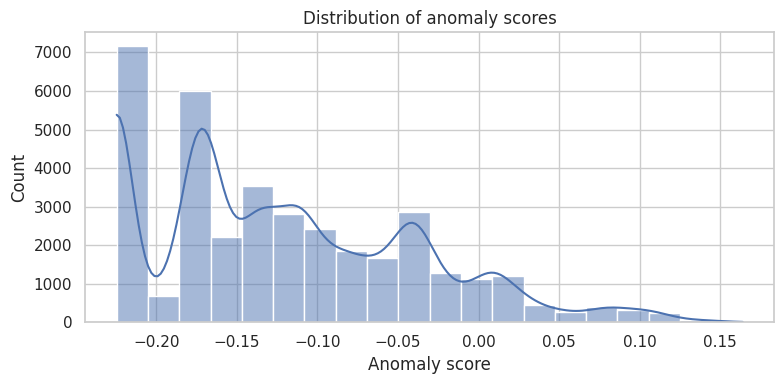

In [15]:
plt.figure(figsize=(8, 4))
if not scored_df.empty and "anomaly_score" in scored_df.columns:
    sns.histplot(scored_df["anomaly_score"], bins=20, kde=True)
    plt.title("Distribution of anomaly scores")
    plt.xlabel("Anomaly score")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

In [16]:
# Ensemble Anomaly Detection with Temporal Trend Analysis
# This unique feature combines multiple anomaly detectors and tracks species trends over time.

def ensemble_anomaly_detection(feature_df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensemble anomaly detection combining Isolation Forest, statistical methods, and density signals.
    Returns feature dataframe with combined ensemble anomaly score.
    """
    if feature_df.empty:
        return feature_df
    
    df = feature_df.copy()
    
    # Ensure all numeric columns exist
    for col in numeric_cols:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)
    
    model_input = df[numeric_cols].fillna(0.0).astype(float)
    
    # 1. Isolation Forest (primary)
    try:
        iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=config.random_seed, n_jobs=1)
        iso_forest.fit(model_input)
        iso_scores = -iso_forest.decision_function(model_input)
    except Exception:
        iso_scores = np.zeros(len(df))
    
    # 2. Statistical Z-score (catches statistical outliers)
    try:
        scaler = StandardScaler()
        scaled = scaler.fit_transform(model_input)
        z_scores = np.sqrt(np.sum(scaled ** 2, axis=1))
    except Exception:
        z_scores = np.zeros(len(df))
    
    # 3. Local outlier factor approximation (density-based)
    try:
        from sklearn.neighbors import NearestNeighbors
        nbrs = NearestNeighbors(n_neighbors=20, n_jobs=1).fit(model_input)
        distances, _ = nbrs.kneighbors(model_input)
        k_distances = distances[:, -1]
        lof_approx = k_distances / (k_distances.mean() + 1.001e-6)
    except Exception:
        lof_approx = np.ones(len(df))
    
    # Normalize and combine
    def normalize(arr):
        return (arr - arr.min()) / (arr.max() - arr.min() + 1.001e-6)
    
    df["iso_score"] = normalize(iso_scores)
    df["z_score_norm"] = normalize(z_scores)
    df["lof_score"] = normalize(lof_approx)
    
    # Weighted ensemble: IF > Z-score > LOF
    df["ensemble_anomaly"] = (
        0.55 * df["iso_score"] +
        0.25 * df["z_score_norm"] +
        0.20 * df["lof_score"]
    )
    
    return df


def analyze_species_trends(events_df: pd.DataFrame, window_days: int = 30):
    """
    Analyze temporal trends in species sightings per camera.
    Returns DataFrame with trend info and dict of SPECIES_TRENDS.
    """
    if events_df.empty or "start_time" not in events_df.columns:
        return pd.DataFrame(), {}
    
    df = events_df.copy()
    if "dominant_species" not in df.columns:
        if "species_counts" in df.columns:
            df["dominant_species"] = df["species_counts"].apply(
                lambda value: max(parse_species_counts(value), key=parse_species_counts(value).get)
                if parse_species_counts(value) else None
            )
        else:
            df["dominant_species"] = None
    df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
    df = df.dropna(subset=["start_time"])
    
    if df.empty:
        return pd.DataFrame(), {}
    
    df["window"] = df["start_time"].dt.floor(f"{window_days}D")
    
    trends = []
    for species in df["dominant_species"].dropna().unique():
        species_df = df[df["dominant_species"] == species].copy()
        if len(species_df) < 3:
            continue
        
        window_counts = species_df.groupby("window").size().reset_index(name="count")
        window_counts = window_counts.sort_values("window")
        
        if len(window_counts) < 2:
            continue
        
        x = np.arange(len(window_counts))
        y = window_counts["count"].values
        slope, _ = np.polyfit(x, y, 1)
        
        trends.append({
            "species": species,
            "trend_slope": slope,
            "trend_direction": "increasing" if slope > 0.1 else "decreasing" if slope < -0.1 else "stable",
            "avg_count": y.mean(),
            "max_count": y.max(),
            "min_count": y.min(),
            "total_observations": len(species_df),
        })
    
    trends_df = pd.DataFrame(trends)
    species_trends = {}
    if not trends_df.empty:
        species_trends = trends_df.set_index("species")["trend_direction"].to_dict()
    
    return trends_df, species_trends

# Apply ensemble detection
print("Running ensemble anomaly detection...")
scored_df = ensemble_anomaly_detection(scored_df)
print(f"  Ensemble scores: min={scored_df['ensemble_anomaly'].min():.4f}, max={scored_df['ensemble_anomaly'].max():.4f}")

# Analyze trends
print("Analyzing species trends...")
trends_df, SPECIES_TRENDS = analyze_species_trends(events_df, window_days=30)
if not trends_df.empty:
    print(f"  Found trends for {len(trends_df)} species")
    print("  Trend summary:")
    print(trends_df[["species", "trend_direction", "avg_count"]].to_string(index=False))
else:
    print("  No significant trends detected.")
    SPECIES_TRENDS = {}

print("\nEnsemble anomaly detection and temporal trend analysis complete.")

Running ensemble anomaly detection...
  Ensemble scores: min=0.0321, max=0.8686
Analyzing species trends...
  Found trends for 120 species
  Trend summary:
                 species trend_direction   avg_count
                   empty      decreasing 1214.428571
  cephalophus nigrifrons      increasing  127.428571
       madoqua guentheri      increasing  209.750000
          capra aegagrus      increasing   29.500000
      loxodonta africana      decreasing  118.250000
      aepyceros melampus      decreasing  317.250000
     francolinus nobilis      decreasing   26.285714
            equus quagga      decreasing   84.750000
     atherurus africanus      decreasing   26.166667
              bos taurus      decreasing  142.750000
    acryllium vulturinum      decreasing   24.250000
  potamochoerus larvatus      decreasing   12.600000
         syncerus caffer      decreasing   60.000000
            equus grevyi      decreasing   38.250000
    cricetomys gambianus      increasing   58.428

In [17]:
# Camera Health Score and Deployment Quality Metrics
# Unique feature: Evaluates camera deployment quality and detection reliability

def compute_camera_health_score(events_df: pd.DataFrame) -> pd.DataFrame:
    """
    Compute a health score for each camera based on detection consistency,
    species diversity, and temporal coverage.
    
    Returns dataframe with camera_id and health metrics.
    """
    if events_df.empty or "camera_id" not in events_df.columns:
        return pd.DataFrame()
    
    df = events_df.copy()
    
    # Ensure timestamp
    if "start_time" in df.columns:
        df["start_time"] = pd.to_datetime(df["start_time"], errors="coerce")
    
    camera_stats = []
    
    for camera_id, group in df.groupby("camera_id"):
        # 1. Detection consistency (detections per day)
        if "start_time" in group.columns:
            days = (group["start_time"].max() - group["start_time"].min()).days + 1
            detections_per_day = len(group) / max(days, 1)
        else:
            detections_per_day = len(group)
        
        # 2. Species diversity (Shannon entropy)
        if "species_counts_parsed" in group.columns:
            all_species = {}
            for counts in group["species_counts_parsed"]:
                if isinstance(counts, dict):
                    for sp, count in counts.items():
                        all_species[sp] = all_species.get(sp, 0) + count
            
            if all_species:
                total = sum(all_species.values())
                probs = [c / total for c in all_species.values()]
                shannon_entropy = -sum(p * math.log(p + 1e-6) for p in probs)
            else:
                shannon_entropy = 0
            species_richness = len(all_species)
        else:
            shannon_entropy = 0
            species_richness = group["dominant_species"].nunique() if "dominant_species" in group.columns else 0
        
        # 3. Temporal coverage (how well camera covers 24h)
        if "start_time" in group.columns:
            df_time = group.dropna(subset=["start_time"]).copy()
            if not df_time.empty:
                df_time["hour"] = df_time["start_time"].dt.hour
                hours_covered = df_time["hour"].nunique()
                temporal_coverage = hours_covered / 24.0
            else:
                temporal_coverage = 0
        else:
            temporal_coverage = 0
        
        # 4. Data quality (non-null values ratio)
        total_cells = group.size
        null_cells = group.isna().sum().sum()
        data_quality = 1.0 - (null_cells / max(total_cells, 1))
        
        # Composite health score (0-1, higher is better)
        # Normalize each component
        det_score = min(detections_per_day / 10.0, 1.0)  # Cap at 10 detections/day
        div_score = min(shannon_entropy / 3.0, 1.0)      # Cap entropy at 3
        temp_score = temporal_coverage
        qual_score = data_quality
        
        health_score = (
            0.30 * det_score +
            0.25 * div_score +
            0.20 * temp_score +
            0.25 * qual_score
        )
        
        camera_stats.append({
            "camera_id": camera_id,
            "health_score": round(health_score, 4),
            "detections_per_day": round(detections_per_day, 2),
            "species_richness": species_richness,
            "shannon_diversity": round(shannon_entropy, 4),
            "temporal_coverage": round(temporal_coverage, 4),
            "data_quality": round(qual_score, 4),
            "total_events": len(group),
        })
    
    return pd.DataFrame(camera_stats).sort_values("health_score", ascending=False)

# Compute camera health scores
print("Computing camera health scores...")
camera_health = compute_camera_health_score(scored_df)
if not camera_health.empty:
    print(f"  Computed health for {len(camera_health)} cameras")
    print("  Top 5 cameras by health:")
    print(camera_health.head()[["camera_id", "health_score", "species_richness", "temporal_coverage"]].to_string(index=False))
    print("\n  Bottom 5 cameras by health:")
    print(camera_health.tail()[["camera_id", "health_score", "species_richness", "temporal_coverage"]].to_string(index=False))
else:
    print("  No camera health data available.")

# Add health score merge to scored_df if available
if not camera_health.empty and "camera_id" in scored_df.columns:
    scored_df = scored_df.merge(camera_health[["camera_id", "health_score"]], on="camera_id", how="left")
    scored_df["health_score"] = scored_df["health_score"].fillna(0.5)
    print("  Health score merged into scored_df")

print("\nCamera health scoring complete.")

Computing camera health scores...
  Computed health for 323 cameras
  Top 5 cameras by health:
 camera_id  health_score  species_richness  temporal_coverage
        51        0.8984                17             1.0000
        10        0.8542                15             0.9583
       501        0.8375                14             0.8750
       499        0.8248                17             0.9583
       522        0.8187                17             0.9583

  Bottom 5 cameras by health:
 camera_id  health_score  species_richness  temporal_coverage
       267        0.2883                 1             0.0417
       143        0.2883                 1             0.0417
       434        0.2883                 1             0.0417
       106        0.2883                 1             0.0417
         0        0.2883                 1             0.0417
  Health score merged into scored_df

Camera health scoring complete.


In [18]:
# Strategy: ecological novelty + conservation impact (information-theoretic, non-ML)
import itertools

if scored_df.empty:
    print("scored_df is empty; skipping ecological novelty scoring.")
else:
    if "species_counts_parsed" not in scored_df.columns:
        scored_df["species_counts_parsed"] = scored_df["species_counts"].apply(parse_species_counts)

    def normalize_dist(counts: dict) -> dict:
        total = float(sum(counts.values()))
        if total <= 0:
            return {}
        return {key: float(value) / total for key, value in counts.items()}

    def js_divergence(counts_a: dict, counts_b: dict) -> float:
        p = normalize_dist(counts_a)
        q = normalize_dist(counts_b)
        if not p or not q:
            return 0.0
        keys = sorted(set(p) | set(q))
        p_vec = np.array([p.get(k, 0.0) for k in keys], dtype=float)
        q_vec = np.array([q.get(k, 0.0) for k in keys], dtype=float)
        p_vec = p_vec / (p_vec.sum() + 1e-12)
        q_vec = q_vec / (q_vec.sum() + 1e-12)
        m_vec = 0.5 * (p_vec + q_vec)
        def kl_div(x, y):
            return float(np.sum(np.where(x > 0, x * np.log((x + 1e-12) / (y + 1e-12)), 0.0)))
        return 0.5 * (kl_div(p_vec, m_vec) + kl_div(q_vec, m_vec))

    # Build global and camera-level frequency tables
    global_counts = {}
    pair_counts = {}
    camera_counts = {}

    for _, row in scored_df.iterrows():
        counts = row.get("species_counts_parsed", {}) or {}
        camera_id = row.get("camera_id", "camera_unknown")
        if camera_id not in camera_counts:
            camera_counts[camera_id] = {}
        for species, count in counts.items():
            global_counts[species] = global_counts.get(species, 0.0) + float(count)
            camera_counts[camera_id][species] = camera_counts[camera_id].get(species, 0.0) + float(count)
        species_list = sorted(counts.keys())
        for a, b in itertools.combinations(species_list, 2):
            key = tuple(sorted((a, b)))
            pair_counts[key] = pair_counts.get(key, 0.0) + 1.0

    total_species = float(sum(global_counts.values())) or 1.0
    species_prob = {s: c / total_species for s, c in global_counts.items()}
    total_pairs = float(sum(pair_counts.values())) or 1.0
    pair_prob = {k: v / total_pairs for k, v in pair_counts.items()}
    min_species_prob = 1.0 / (total_species * 10.0)
    min_pair_prob = 1.0 / (total_pairs * 10.0)

    def event_surprisal(row: pd.Series) -> pd.Series:
        counts = row.get("species_counts_parsed", {}) or {}
        species_list = sorted(counts.keys())
        species_surprisal = float(sum(-math.log(species_prob.get(s, min_species_prob)) * float(c) for s, c in counts.items()))
        pair_surprisal = 0.0
        for a, b in itertools.combinations(species_list, 2):
            pair_surprisal += -math.log(pair_prob.get(tuple(sorted((a, b))), min_pair_prob))
        camera_id = row.get("camera_id", "camera_unknown")
        camera_dist = camera_counts.get(camera_id, {})
        js_score = js_divergence(counts, camera_dist)
        surprisal_score = species_surprisal + pair_surprisal + js_score
        return pd.Series({
            "species_surprisal": species_surprisal,
            "pair_surprisal": pair_surprisal,
            "js_divergence": js_score,
            "surprisal_score": surprisal_score,
        })

    surprisal_df = scored_df.apply(event_surprisal, axis=1)
    scored_df = pd.concat([scored_df, surprisal_df], axis=1)

    # Rolling temporal novelty (camera-level baseline)
    rolling_scores = pd.Series(index=scored_df.index, dtype=float)
    rolling_window = 10
    for camera_id, group in scored_df.sort_values(["camera_id", "start_time"]).groupby("camera_id"):
        history = []
        for idx, row in group.iterrows():
            baseline_counts = {}
            for prev_counts in history[-rolling_window:]:
                for species, count in prev_counts.items():
                    baseline_counts[species] = baseline_counts.get(species, 0.0) + float(count)
            rolling_js = js_divergence(row.get("species_counts_parsed", {}) or {}, baseline_counts) if baseline_counts else 0.0
            rolling_scores.at[idx] = rolling_js
            history.append(row.get("species_counts_parsed", {}) or {})
    scored_df["rolling_js"] = rolling_scores.fillna(0.0)
    scored_df["surprisal_score"] = scored_df["surprisal_score"].fillna(0.0) + scored_df["rolling_js"]

    # Conservation impact signals (risk + coverage + entropy shift)
    RISK_WEIGHTS = {
        "elephant": 2.0,
        "giraffe": 1.7,
        "zebra": 1.4,
        "wildebeest": 1.3,
        "gazelle": 1.1,
    }

    def event_entropy(counts: dict) -> float:
        dist = normalize_dist(counts)
        if not dist:
            return 0.0
        return float(-sum(p * math.log(p + 1e-12) for p in dist.values()))

    def risk_score(counts: dict) -> float:
        total = float(sum(counts.values()))
        if total <= 0:
            return 0.0
        weighted = 0.0
        for species, count in counts.items():
            key = str(species).lower()
            weighted += RISK_WEIGHTS.get(key, 1.0) * float(count)
        return weighted / total

    camera_entropy = {camera_id: event_entropy(counts) for camera_id, counts in camera_counts.items()}
    scored_df["event_entropy"] = scored_df["species_counts_parsed"].apply(event_entropy)
    scored_df["camera_entropy"] = scored_df["camera_id"].map(camera_entropy).fillna(0.0)
    scored_df["entropy_shift"] = (scored_df["event_entropy"] - scored_df["camera_entropy"]).abs()
    scored_df["risk_score"] = scored_df["species_counts_parsed"].apply(risk_score)

    camera_event_counts = scored_df["camera_id"].value_counts()
    species_event_counts = {}
    for species_list in scored_df["species_list"]:
        if isinstance(species_list, list):
            for species in species_list:
                species_event_counts[species] = species_event_counts.get(species, 0) + 1

    def coverage_score(row: pd.Series) -> float:
        camera_id = row.get("camera_id", "camera_unknown")
        cam_weight = 1.0 / math.sqrt(float(camera_event_counts.get(camera_id, 1)))
        species_list = row.get("species_list")
        if not isinstance(species_list, list):
            species_list = list((row.get("species_counts_parsed", {}) or {}).keys())
        if not species_list:
            return cam_weight
        species_weights = [1.0 / math.sqrt(float(species_event_counts.get(s, 1))) for s in species_list]
        return cam_weight * float(np.mean(species_weights))

    scored_df["coverage_score"] = scored_df.apply(coverage_score, axis=1)
    scored_df["eco_novelty"] = (
        scored_df["surprisal_score"].fillna(0.0)
        + scored_df["entropy_shift"].fillna(0.0)
        + scored_df["rolling_js"].fillna(0.0)
)
    print("Ecological novelty and conservation impact scores added to scored_df")

Ecological novelty and conservation impact scores added to scored_df


In [19]:
# Strategy: camera-aware burst scoring for better prioritization

def median_abs_dev(series: pd.Series) -> float:
    values = pd.to_numeric(series, errors="coerce").dropna().astype(float)
    if values.empty:
        return 1.0
    median = float(np.median(values))
    mad = float(np.median(np.abs(values - median)))
    return mad if mad > 0 else 1.0

def minmax_scale(series: pd.Series) -> pd.Series:
    values = pd.to_numeric(series, errors="coerce").fillna(0.0).astype(float)
    denom = values.max() - values.min()
    if denom == 0:
        return values * 0.0
    return (values - values.min()) / (denom + 1e-6)

def add_priority_scores(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty:
        return df
    out = df.copy()
    out["camera_median"] = out.groupby("camera_id")["total_animals"].transform("median")
    out["camera_mad"] = out.groupby("camera_id")["total_animals"].transform(median_abs_dev)
    out["burst_score"] = (out["total_animals"] - out["camera_median"]) / (out["camera_mad"] + 1.0)
    out["burst_score"] = out["burst_score"].clip(lower=-5.0, upper=5.0)

    out["norm_anomaly"] = minmax_scale(out["anomaly_score"]) if "anomaly_score" in out.columns else 0.0
    out["norm_rarity"] = minmax_scale(out["species_rarity_score"]) if "species_rarity_score" in out.columns else 0.0
    out["norm_temporal"] = minmax_scale(out["temporal_change"].abs()) if "temporal_change" in out.columns else 0.0
    out["norm_seasonal"] = minmax_scale(out["seasonal_dev"].abs()) if "seasonal_dev" in out.columns else 0.0
    out["norm_burst"] = minmax_scale(out["burst_score"].abs())
    if "eco_novelty" in out.columns:
        out["norm_eco"] = minmax_scale(out["eco_novelty"])
    else:
        out["norm_eco"] = minmax_scale(out["surprisal_score"]) if "surprisal_score" in out.columns else 0.0
    out["norm_risk"] = minmax_scale(out["risk_score"]) if "risk_score" in out.columns else 0.0
    out["norm_coverage"] = minmax_scale(out["coverage_score"]) if "coverage_score" in out.columns else 0.0

    out["priority_score"] = (
        0.15 * out["norm_anomaly"] +
        0.20 * out["norm_eco"] +
        0.10 * out["norm_rarity"] +
        0.15 * out["norm_risk"] +
        0.10 * out["norm_coverage"] +
        0.15 * out["norm_burst"] +
        0.10 * out["norm_temporal"] +
        0.05 * out["norm_seasonal"]
)
    out["priority_rank"] = out["priority_score"].rank(ascending=False, method="dense").astype(int)
    return out

scored_df = add_priority_scores(scored_df)
scored_df[["event_id", "camera_id", "priority_score", "priority_rank"]].head()

,event_id,camera_id,priority_score,priority_rank
0,975e82fe-21bc-11ea-a13a-137349068a90,0,0.089135,16787
1,302f1138-7d42-11eb-8fb5-0242ac1c0002,1,0.485957,87
2,302f11ba-7d42-11eb-8fb5-0242ac1c0002,1,0.319757,1767
3,9766b186-21bc-11ea-a13a-137349068a90,1,0.225839,6055
4,94471b3a-21bc-11ea-a13a-137349068a90,1,0.070216,18618


### Analysis Visualizations (Data → Anomaly)

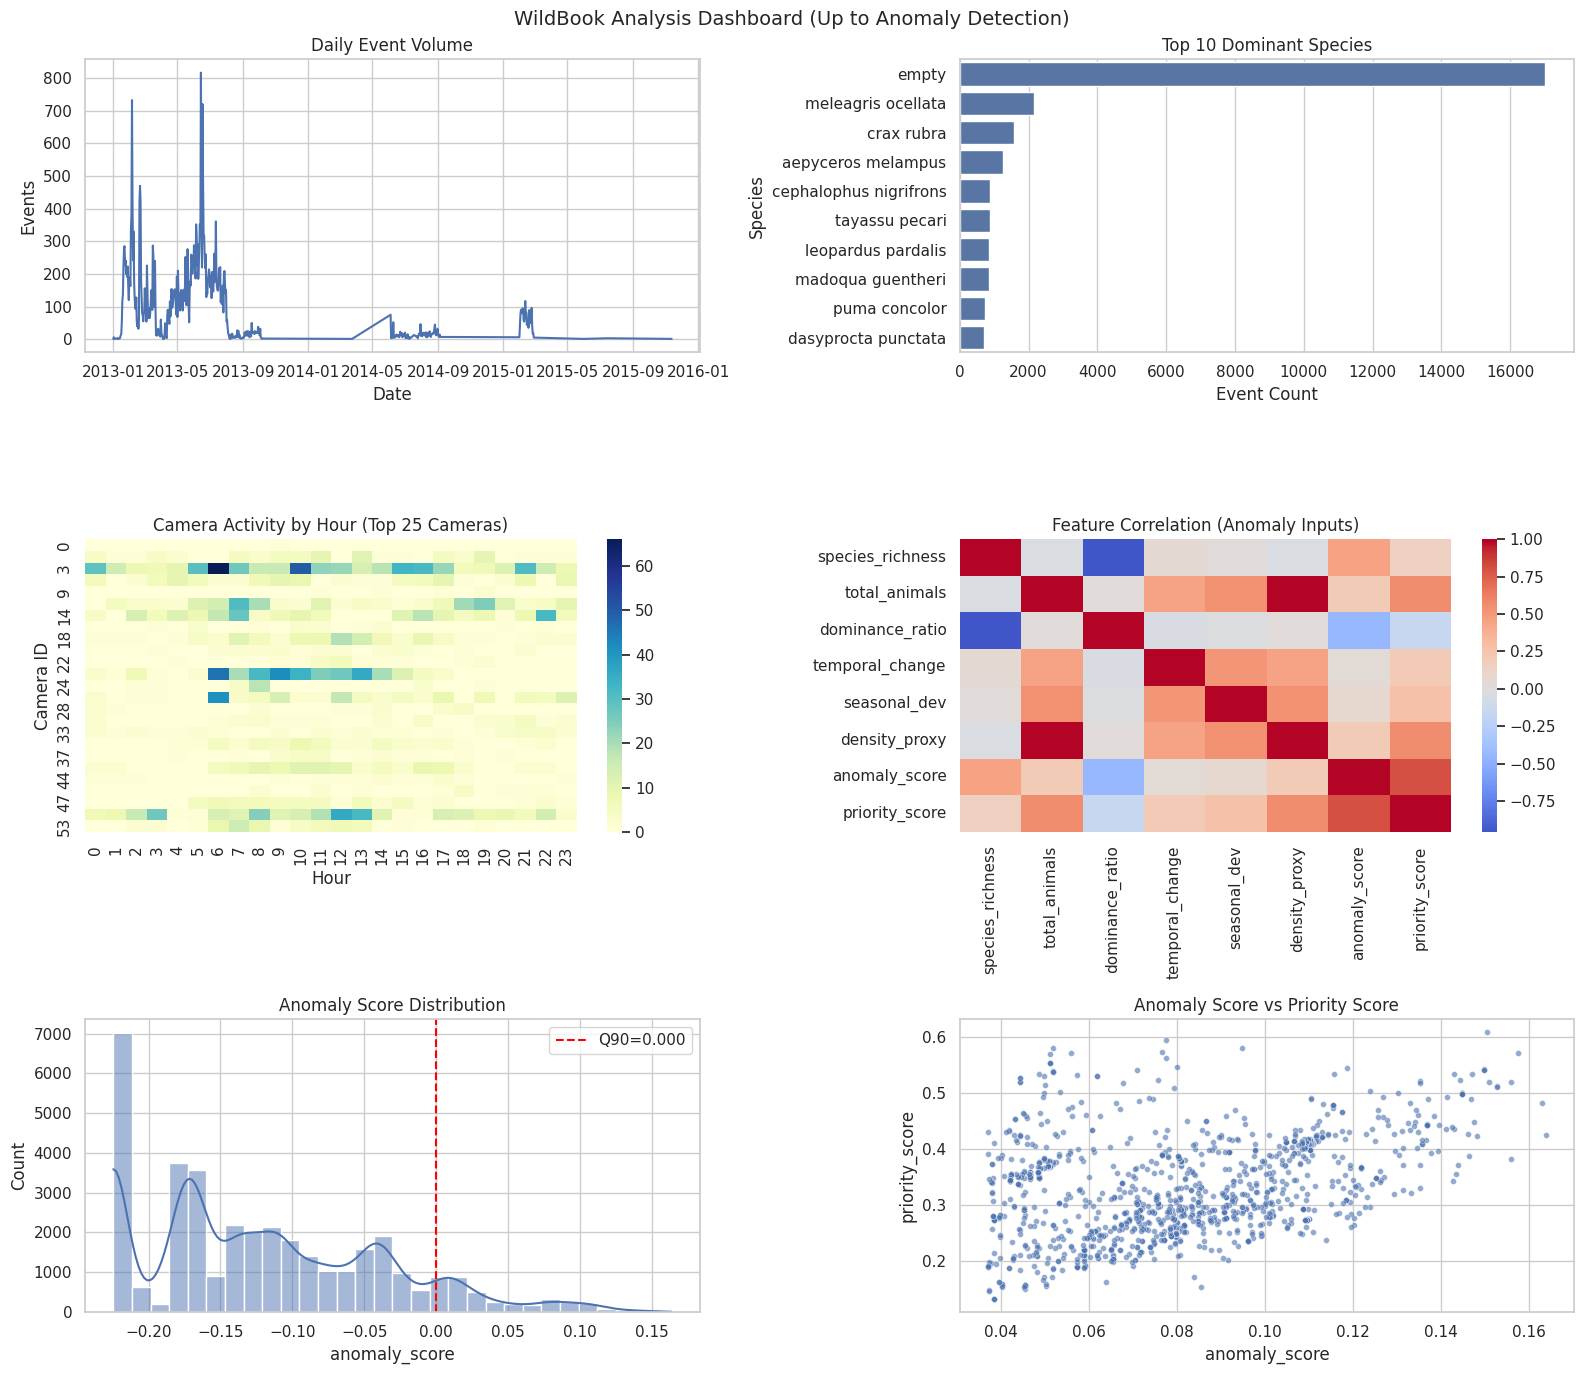

In [20]:
def plot_analysis_dashboard(events_df: pd.DataFrame, scored_df: pd.DataFrame) -> None:
    """
    Contextual plots for pipeline health up to anomaly detection.
    Safe for Kaggle notebook execution.
    """
    sns.set_style("whitegrid")
    if events_df is None or scored_df is None:
        return

    events = events_df.copy()
    scored = scored_df.copy()

    if "start_time" in events.columns:
        events["start_time"] = pd.to_datetime(events["start_time"], errors="coerce")
    if "start_time" in scored.columns:
        scored["start_time"] = pd.to_datetime(scored["start_time"], errors="coerce")

    fig, axes = plt.subplots(3, 2, figsize=(16, 14))
    fig.suptitle("WildBook Analysis Dashboard (Up to Anomaly Detection)", fontsize=14)

    ax = axes[0, 0]
    if "start_time" in events.columns:
        daily = events.dropna(subset=["start_time"]).groupby(events["start_time"].dt.date).size()
        daily.plot(ax=ax)
        ax.set_title("Daily Event Volume")
        ax.set_xlabel("Date")
        ax.set_ylabel("Events")
    else:
        ax.set_title("Daily Event Volume (missing start_time)")

    ax = axes[0, 1]
    if "dominant_species" in scored.columns:
        top_species = scored["dominant_species"].astype(str).value_counts().head(10)
        sns.barplot(x=top_species.values, y=top_species.index, ax=ax)
        ax.set_title("Top 10 Dominant Species")
        ax.set_xlabel("Event Count")
        ax.set_ylabel("Species")
    else:
        ax.set_title("Top Species (missing dominant_species)")

    ax = axes[1, 0]
    if {"camera_id", "start_time"}.issubset(scored.columns):
        tmp = scored.dropna(subset=["start_time"]).copy()
        tmp["hour"] = tmp["start_time"].dt.hour
        cam_hour = tmp.pivot_table(index="camera_id", columns="hour", values="event_id", aggfunc="count", fill_value=0)
        cam_hour = cam_hour.head(25)
        sns.heatmap(cam_hour, cmap="YlGnBu", ax=ax)
        ax.set_title("Camera Activity by Hour (Top 25 Cameras)")
        ax.set_xlabel("Hour")
        ax.set_ylabel("Camera ID")
    else:
        ax.set_title("Camera Activity Heatmap (missing camera_id/start_time)")

    ax = axes[1, 1]
    feature_cols = [
        "species_richness", "total_animals", "dominance_ratio",
        "temporal_change", "seasonal_dev", "density_proxy",
        "anomaly_score", "priority_score"
    ]
    avail = [col for col in feature_cols if col in scored.columns]
    if len(avail) >= 3:
        corr = scored[avail].corr(numeric_only=True)
        sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
        ax.set_title("Feature Correlation (Anomaly Inputs)")
    else:
        ax.set_title("Feature Correlation (insufficient numeric columns)")

    ax = axes[2, 0]
    if "anomaly_score" in scored.columns:
        sns.histplot(scored["anomaly_score"], bins=30, kde=True, ax=ax)
        threshold = float(scored["anomaly_score"].quantile(0.90))
        ax.axvline(threshold, color="red", linestyle="--", label=f"Q90={threshold:.3f}")
        ax.legend()
        ax.set_title("Anomaly Score Distribution")
    else:
        ax.set_title("Anomaly Distribution (missing anomaly_score)")

    ax = axes[2, 1]
    if {"anomaly_score", "priority_score"}.issubset(scored.columns):
        top = scored.nlargest(min(1500, len(scored)), "anomaly_score")
        sns.scatterplot(data=top, x="anomaly_score", y="priority_score", s=18, alpha=0.6, ax=ax)
        ax.set_title("Anomaly Score vs Priority Score")
    else:
        ax.set_title("Anomaly vs Priority (missing required columns)")

    plt.tight_layout()
    plt.show()

plot_analysis_dashboard(events_df=events_df, scored_df=scored_df)

In [21]:
# Safety guards for training data availability
CATEGORY_MAP = globals().get("CATEGORY_MAP", {})
if "scored_df" not in globals():
    print("scored_df not found. Run anomaly detection before fine-tuning.")
    scored_df = pd.DataFrame()

## 7A. Fine-tune Gemma 4 with Unsloth

This section demonstrates domain adaptation for wildlife ecology. Using Unsloth reduces memory overhead by ~70% and speeds up training ~4-8x.


**What we're tuning for**: Wildlife ecology, ranger communication, conservation priorities.

In [22]:
# STEP 1: Suppress pip and syntax warnings for cleaner logs
import warnings
import os
import subprocess
import sys
import random
import re

warnings.filterwarnings("ignore", message=".*fsspec.*", category=Warning)
warnings.filterwarnings("ignore", message=".*bigframes.*", category=Warning)
warnings.filterwarnings("ignore", message=".*invalid escape sequence.*", category=SyntaxWarning)
os.environ["PIP_NO_WARN_SCRIPT_LOCATION"] = "0"
os.environ["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

# STEP 2: Install Unsloth and dependencies
def install_unsloth():
    """Install Unsloth for T4 GPU fine-tuning with 4-bit quantization."""
    try:
        import unsloth  # noqa: F401
        print("Unsloth already installed")
        return True
    except ImportError:
        print("Installing Unsloth for Kaggle GPU...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "unsloth[kaggle]"])
        print("Unsloth installed successfully")
        return True

install_unsloth()

# STEP 3: Load the Unsloth Gemma-4 model with a 4-bit -> fp16 fallback
from unsloth import FastLanguageModel
import torch
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling
from datasets import Dataset
from pathlib import Path

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
torch.backends.cuda.matmul.allow_tf32 = True

def get_free_vram_gb() -> float:
    if not torch.cuda.is_available():
        return 0.0
    try:
        free_bytes, _ = torch.cuda.mem_get_info()
        return free_bytes / 1e9
    except Exception:
        props = torch.cuda.get_device_properties(0)
        return props.total_memory / 1e9

def pick_max_seq_length(free_gb: float) -> int:
    if free_gb < 6.0:
        return 128
    if free_gb < 9.0:
        return 192
    return 256

GPU_COUNT = torch.cuda.device_count()
FREE_VRAM_GB = get_free_vram_gb()
ENABLE_FINETUNE = torch.cuda.is_available()
SEED = getattr(config, "random_seed", 42)

MAX_SEQ_LENGTH = pick_max_seq_length(FREE_VRAM_GB)
LORA_R = 4 if FREE_VRAM_GB >= 6.0 else 2

print(f"CUDA devices: {GPU_COUNT}, free VRAM: {FREE_VRAM_GB:.2f} GB")
print(f"Max seq length: {MAX_SEQ_LENGTH}, LoRA r: {LORA_R}")
if GPU_COUNT > 1:
    print("Multiple GPUs detected; training will use a single GPU for stability.")
if not ENABLE_FINETUNE:
    print("CUDA not available. Fine-tuning will be skipped.")

UNSLOTH_MODEL_ID = "unsloth/gemma-4-E2B-it-unsloth-bnb-4bit"

def load_unsloth_model(model_id: str):
    """Load a Gemma-4 model using Unsloth with a 4-bit -> fp16 fallback."""
    try:
        model, tokenizer = FastLanguageModel.from_pretrained(
            model_name=model_id,
            max_seq_length=MAX_SEQ_LENGTH,
            dtype=torch.float16,
            load_in_4bit=True,
            trust_remote_code=True,
        )
        print(f"Loaded {model_id} with Unsloth (4-bit)")
        return model, tokenizer, "4bit"
    except Exception as e:
        msg = str(e).lower()
        if "normal_kernel_cuda" in msg or "byte" in msg:
            print("4-bit load failed (missing CUDA kernel for uint8). Switching to fp16.")
            model, tokenizer = FastLanguageModel.from_pretrained(
                model_name=model_id,
                max_seq_length=MAX_SEQ_LENGTH,
                dtype=torch.float16,
                load_in_4bit=False,
                trust_remote_code=True,
            )
            print(f"Loaded {model_id} with Unsloth (fp16 fallback)")
            return model, tokenizer, "fp16"
        raise

try:
    model, tokenizer, load_mode = load_unsloth_model(UNSLOTH_MODEL_ID)
    print(f"Device: {model.device}")
    print(f"Dtype: {model.dtype}")
except Exception as e:
    print(f"Error loading Unsloth model: {e}")
    raise

text_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer
if text_tokenizer.pad_token is None:
    text_tokenizer.pad_token = text_tokenizer.eos_token
text_tokenizer.padding_side = "right"
if hasattr(tokenizer, "padding_side"):
    tokenizer.padding_side = "right"
chat_template_source = tokenizer if hasattr(tokenizer, "apply_chat_template") else text_tokenizer

# STEP 4: Configure LoRA adapters for parameter-efficient fine-tuning
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    lora_alpha=LORA_R * 2,
    lora_dropout=0.0,
    bias="none",
    use_gradient_checkpointing=True,
    use_rslora=False,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

print("LoRA adapters configured")
print("Trainable parameters: only LoRA weights")

if hasattr(model, "config"):
    model.config.use_cache = False

if hasattr(FastLanguageModel, "for_training"):
    try:
        model = FastLanguageModel.for_training(model)
    except Exception:
        pass

# Alias for later inference cells (use the fine-tuned model)
gemma_model = model
gemma_processor = tokenizer

# STEP 5: Ensure scored_df is available for training
if "scored_df" not in globals() or scored_df.empty:
    if "events_df" in globals() and not events_df.empty:
        print("scored_df empty; rebuilding features for training.")
        feature_df = compute_features(events_df)
        _, scored_df = fit_anomaly_model(feature_df)
    else:
        scored_df = pd.DataFrame()

# STEP 6: Universal system prompt + metadata helpers
UNIVERSAL_SYSTEM_PROMPT = """You are WildBook, a conservation AI co-pilot for camera-trap analysis.

MISSION:
- Turn event data into actionable guidance for wildlife ecology, ranger communication, conservation priorities, and wildlife reserve operations.
- Prioritize safety, clarity, and evidence from the event table.

CONSTRAINTS:
- Use ONLY the provided event data. Do not invent species, locations, or behaviors.
- If a key fact is missing, say "insufficient data."
- Never speculate beyond what the data supports.

CORE REASONING:
1. Identify aggregation patterns (monospecific vs mixed-species, count changes).
2. Link patterns to ecological drivers: water, food, migration, habitat stress, disease.
3. Assess conservation priority: rarity, predation risk, habitat disturbance, temporal anomaly.
4. Recommend ranger action: patrol urgency, monitoring intensity, investigation scope.

OUTPUT FORMAT (unless user specifies otherwise):
- Behavior: Describe the observed group composition and activity.
- Significance: Highlight why this event matters for conservation (rarity, anomaly, ecological signal).
- Action: Provide one concrete, time-bound follow-up action.

ECOLOGICAL KNOWLEDGE:
- High aggregation + low species diversity -> possible stress response (water, food, disturbance).
- High species diversity + unusual composition -> migration window or ecosystem health shift.
- Seasonal deviation + temporal spike -> climate pressure or human impact.
- Temporal stability + moderate numbers -> baseline, continue routine monitoring.

RANGER CONTEXT:
- You write for field rangers with limited time and resources.
- Be concise: 3 sentences max per event.
- Be actionable: every recommendation must be doable within a ranger's capacity.
- Be honest: if data is insufficient, say so.

DEPLOY WITH iWILDCAM ONLY:
- This prompt is for iWildCam events and splits only.
- Features (species richness, temporal change, anomaly score) are stable across iWildCam event data.
- Only the held-out camera traps and time blocks change; the reasoning pattern is fixed.
"""

def save_prompt_to_model_config(model, prompt_text: str):
    if hasattr(model, "config"):
        model.config.wildbook_system_prompt = prompt_text
    return model

model = save_prompt_to_model_config(model, UNIVERSAL_SYSTEM_PROMPT)
TRAIN_SYSTEM_PROMPT = UNIVERSAL_SYSTEM_PROMPT

FEATURE_SCHEMA = [
    "total_animals", "species_richness", "dominance_ratio",
    "temporal_change", "seasonal_dev", "density_proxy",
    "anomaly_score", "priority_score", "eco_novelty",
]

EXPORT_DIR = Path("./WildBook-Gemma")
ADAPTER_DIR = EXPORT_DIR / "lora_adapters"
MERGED_DIR = EXPORT_DIR / "merged_16bit"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

DATA_MANIFEST_PATH = OUTPUT_DIR / "dataset_manifest.json"
RAW_COPY_PATH = OUTPUT_DIR / "events_raw_copy.csv"
if "events_df" in globals() and isinstance(events_df, pd.DataFrame) and not events_df.empty:
    if not RAW_COPY_PATH.exists():
        events_df.to_csv(RAW_COPY_PATH, index=False)
    dataset_manifest = {
        "source": str(DATA_LAYOUT.get("metadata_dir") or ""),
        "events_raw_copy": str(RAW_COPY_PATH),
        "notes": "Raw iWildCam data not modified; working copy stored under outputs.",
    }
    with open(DATA_MANIFEST_PATH, "w", encoding="utf-8") as handle:
        json.dump(dataset_manifest, handle, indent=2)

# STEP 7: Domain-aware split for train/val/test (camera + time blocks)
def domain_aware_split(
    df: pd.DataFrame,
    train_frac: float = 0.7,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
    seed: int = 42,
    ):
    if df.empty:
        return df, df, df
    split_df = df.copy()
    if "camera_id" not in split_df.columns:
        split_df["camera_id"] = "camera_unknown"
    split_df["camera_id"] = split_df["camera_id"].astype(str)
    if "start_time" in split_df.columns:
        split_df["start_time"] = pd.to_datetime(split_df["start_time"], errors="coerce")
        split_df["time_block"] = split_df["start_time"].dt.to_period("Q").astype(str)
    else:
        split_df["time_block"] = "unknown"

    cameras = split_df["camera_id"].dropna().unique().tolist()
    rng = np.random.RandomState(seed)
    rng.shuffle(cameras)
    n_total = len(cameras)
    n_train = max(1, int(n_total * train_frac))
    n_val = max(1, int(n_total * val_frac))
    train_cams = set(cameras[:n_train])
    val_cams = set(cameras[n_train:n_train + n_val])
    test_cams = set(cameras[n_train + n_val:])

    train_df = split_df[split_df["camera_id"].isin(train_cams)].copy()
    val_df = split_df[split_df["camera_id"].isin(val_cams)].copy()
    test_df = split_df[split_df["camera_id"].isin(test_cams)].copy()

    if train_df.empty or val_df.empty or test_df.empty:
        blocks = sorted(split_df["time_block"].dropna().unique().tolist())
        if not blocks:
            return split_df, split_df.iloc[0:0], split_df.iloc[0:0]
        n_blocks = len(blocks)
        n_train_b = max(1, int(n_blocks * train_frac))
        n_val_b = max(1, int(n_blocks * val_frac))
        train_blocks = set(blocks[:n_train_b])
        val_blocks = set(blocks[n_train_b:n_train_b + n_val_b])
        test_blocks = set(blocks[n_train_b + n_val_b:])
        train_df = split_df[split_df["time_block"].isin(train_blocks)].copy()
        val_df = split_df[split_df["time_block"].isin(val_blocks)].copy()
        test_df = split_df[split_df["time_block"].isin(test_blocks)].copy()

    return train_df, val_df, test_df

train_df, val_df, test_df = domain_aware_split(scored_df, seed=SEED)
print(f"Split sizes: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print(
    f"Unique cameras: train={train_df['camera_id'].nunique() if not train_df.empty else 0}, "
    f"val={val_df['camera_id'].nunique() if not val_df.empty else 0}, "
    f"test={test_df['camera_id'].nunique() if not test_df.empty else 0}"
)

# STEP 8: Build training data from real event rows (train/val/test)
USE_EVENT_ROWS_FOR_LORA = True
MAX_TRAIN_SAMPLES = 500 if FREE_VRAM_GB >= 12.0 else 200
MAX_EVAL_SAMPLES = 120 if FREE_VRAM_GB >= 12.0 else 60
MAX_TEST_SAMPLES = 120 if FREE_VRAM_GB >= 12.0 else 60

def resolve_species_label(value) -> str:
    text = str(value)
    if text.isdigit() and CATEGORY_MAP:
        return CATEGORY_MAP.get(int(text), text)
    return text

def format_species_counts(species_counts: dict) -> str:
    if not species_counts:
        return "unknown"
    parts = []
    for key, count in species_counts.items():
        label = resolve_species_label(key)
        parts.append(f"{label}: {int(count)}")
    return ", ".join(parts)

def augment_row_counts(row, jitter_scale: float = 0.05):
    if row is None:
        return row
    r = row.copy()
    if "total_animals" in r:
        noise = int(np.round(float(r["total_animals"]) * jitter_scale * np.random.randn()))
        r["total_animals"] = max(0, int(r["total_animals"]) + noise)
    return r

def mask_species_in_prompt(prompt: str, mask_prob: float = 0.15) -> str:
    if not isinstance(prompt, str):
        return ""
    if np.random.rand() < mask_prob:
        return re.sub(r"[A-Za-z_]+\s?[a-z]*", "species_x", prompt, count=1)
    return prompt

def build_training_pair(row: pd.Series):
    species_counts = parse_species_counts(row.get("species_counts"))
    species_bits = format_species_counts(species_counts)
    dominant_species = row.get("dominant_species")
    if dominant_species is None and species_counts:
        dominant_species = max(species_counts, key=species_counts.get)
    dominant_species = resolve_species_label(dominant_species) if dominant_species is not None else "unknown"

    total_animals = int(row.get("total_animals", 0) or 0)
    anomaly_score = float(row.get("anomaly_score", 0.0) or 0.0)
    temporal_change = int(row.get("temporal_change", 0) or 0)
    seasonal_dev = float(row.get("seasonal_dev", 0.0) or 0.0)
    burst_score = float(row.get("burst_score", 0.0) or 0.0)
    is_anomaly = bool(row.get("is_anomaly", False))

    prompt = (
        "Event Summary:\n"
        f"- Camera: {row.get('camera_id', 'unknown')}\n"
        f"- Time window: {row.get('start_time')} to {row.get('end_time')}\n"
        f"- Species observed: {species_bits}\n"
        f"- Total animals: {total_animals}\n"
        f"- Dominant species: {dominant_species}\n"
        f"- Anomaly score: {anomaly_score:.4f}\n"
        f"- Seasonal deviation: {seasonal_dev:+.2f}\n"
        f"- Burst score: {burst_score:+.2f}\n"
        "Task: Write a 2-3 sentence ranger note with Behavior, Significance, and Action."
    )

    behavior = f"Behavior: {dominant_species} group, total {total_animals} animals."
    if is_anomaly or anomaly_score > 0.15:
        significance = "Significance: Unusual activity flagged by anomaly scoring."
    else:
        significance = "Significance: Activity appears typical for this camera."
    if temporal_change > 5 or burst_score > 1.5:
        action = "Action: Increase monitoring and check nearby water sources."
    elif seasonal_dev > 1.0:
        action = "Action: Review seasonal patterns and verify habitat conditions."
    else:
        action = "Action: Continue routine monitoring."
    response = f"{behavior}\n{significance}\n{action}"
    return prompt, response

def prepare_real_training_rows(
    df: pd.DataFrame,
    max_samples: int,
    seed: int,
    apply_augment: bool = False,
    mask_prob: float = 0.15,
    ):
    if df.empty:
        return []
    sample_df = df.sample(n=min(max_samples, len(df)), random_state=seed)
    rows = []
    for _, row in sample_df.iterrows():
        use_row = augment_row_counts(row) if apply_augment else row
        prompt, response = build_training_pair(use_row)
        if not isinstance(prompt, str) or not isinstance(response, str):
            continue
        if apply_augment:
            prompt = mask_species_in_prompt(prompt, mask_prob=mask_prob)
        rows.append({"prompt": prompt, "response": response})
    random.shuffle(rows)
    return rows

train_rows = []
val_rows = []
test_rows = []
if USE_EVENT_ROWS_FOR_LORA and not train_df.empty:
    train_rows = prepare_real_training_rows(
        train_df,
        MAX_TRAIN_SAMPLES,
        SEED,
        apply_augment=True,
        mask_prob=0.15,
    )
    val_rows = prepare_real_training_rows(
        val_df,
        MAX_EVAL_SAMPLES,
        SEED,
        apply_augment=False,
    )
    test_rows = prepare_real_training_rows(
        test_df,
        MAX_TEST_SAMPLES,
        SEED,
        apply_augment=False,
    )
else:
    print("No scored events available for LoRA training.")

train_dataset = Dataset.from_list(train_rows)
eval_dataset = Dataset.from_list(val_rows)
test_dataset = Dataset.from_list(test_rows)

def format_chat(example):
    messages = [
        {"role": "system", "content": TRAIN_SYSTEM_PROMPT},
        {"role": "user", "content": example["prompt"]},
        {"role": "assistant", "content": example["response"]},
    ]
    example["text"] = chat_template_source.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    if not isinstance(example.get("text"), str):
        example["text"] = ""
    return example

def prepare_chat_dataset(dataset: Dataset) -> Dataset:
    if len(dataset) == 0:
        return dataset
    dataset = dataset.map(format_chat, num_proc=1)
    dataset = dataset.map(lambda ex: {"text": str(ex.get("text", ""))}, num_proc=1)
    dataset = dataset.remove_columns([col for col in dataset.column_names if col != "text"])
    dataset = dataset.filter(lambda ex: isinstance(ex.get("text"), str) and len(ex["text"].strip()) > 0)
    return dataset

train_dataset = prepare_chat_dataset(train_dataset)
eval_dataset = prepare_chat_dataset(eval_dataset)
test_dataset = prepare_chat_dataset(test_dataset)
if len(train_dataset) > 0:
    print(f"Prepared training dataset: {len(train_dataset)} samples")
if len(eval_dataset) > 0:
    print(f"Prepared eval dataset: {len(eval_dataset)} samples")
if len(test_dataset) > 0:
    print(f"Prepared test dataset: {len(test_dataset)} samples")

TRAIN_MANIFEST_PATH = OUTPUT_DIR / "train_manifest.json"
train_manifest = {
    "training_dataset": "iwildcam2021-fgvc8",
    "train_rows": len(train_rows),
    "val_rows": len(val_rows),
    "test_rows": len(test_rows),
    "split_strategy": "domain_aware_camera_time",
    "feature_schema": FEATURE_SCHEMA,
    "augmentation": {"row_jitter": 0.05, "mask_prob": 0.15},
    "seed": SEED,
}
with open(TRAIN_MANIFEST_PATH, "w", encoding="utf-8") as handle:
    json.dump(train_manifest, handle, indent=2)
print(f"Training manifest saved to {TRAIN_MANIFEST_PATH}")

def fit_ood_reference(df: pd.DataFrame, feature_cols):
    if df.empty:
        return None, None
    missing = [col for col in feature_cols if col not in df.columns]
    if missing:
        return None, None
    data = df[feature_cols].fillna(0.0).astype(float).to_numpy()
    if data.shape[0] < 3:
        return None, None
    mean = data.mean(axis=0)
    cov = np.cov(data, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    diffs = data - mean
    distances = np.sqrt(np.einsum("ij,jk,ik->i", diffs, inv_cov, diffs))
    threshold = float(np.quantile(distances, 0.95))
    reference = {"mean": mean, "inv_cov": inv_cov, "cols": feature_cols}
    return reference, threshold

OOD_REFERENCE, OOD_THRESHOLD = fit_ood_reference(train_df, FEATURE_SCHEMA)
if OOD_REFERENCE is not None:
    print(f"OOD threshold set to {OOD_THRESHOLD:.4f}")
else:
    print("OOD reference not available (insufficient training data).")

def tokenize_dataset(dataset: Dataset, max_length: int) -> Dataset:
    if len(dataset) == 0:
        return Dataset.from_list([])
    dataset = dataset.filter(lambda ex: isinstance(ex.get("text"), str) and len(ex["text"].strip()) > 0)
    if len(dataset) == 0:
        return Dataset.from_list([])
    def tokenize_batch(example):
        text = example.get("text")
        if not isinstance(text, str):
            text = ""
        return text_tokenizer(
            text=text,
            truncation=True,
            max_length=max_length,
            padding="max_length",
        )
    return dataset.map(tokenize_batch, remove_columns=["text"], num_proc=1)

def build_training_args(max_steps: int, grad_accum_steps: int) -> TrainingArguments:
    eval_steps = max(5, int(max_steps * 0.2))
    return TrainingArguments(
        output_dir="./unsloth_outputs",
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        gradient_accumulation_steps=grad_accum_steps,
        warmup_steps=max(1, int(max_steps * 0.1)),
        num_train_epochs=1,
        max_steps=max_steps,
        learning_rate=5e-4,
        logging_steps=5,
        eval_strategy="steps",
        eval_steps=eval_steps,
        optim="paged_adamw_8bit",
        weight_decay=0.02,
        lr_scheduler_type="cosine",
        save_strategy="no",
        save_total_limit=0,
        fp16=True,
        bf16=False,
        report_to="none",
        gradient_checkpointing=True,
        max_grad_norm=0.5,
        seed=SEED,
        remove_unused_columns=False,
    )

def build_trainer(tokenized_dataset: Dataset, training_args: TrainingArguments, eval_dataset: Optional[Dataset] = None) -> Trainer:
    data_collator = DataCollatorForLanguageModeling(tokenizer=text_tokenizer, mlm=False)
    return Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator,
    )

def strip_notebook_callback(trainer: Trainer) -> Trainer:
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass
    return trainer

def safe_evaluate(trainer: Trainer, dataset: Optional[Dataset]):
    if dataset is None or len(dataset) == 0:
        return None
    try:
        return trainer.evaluate(dataset)
    except RuntimeError as e:
        if "on_train_begin must be called before on_evaluate" in str(e):
            trainer = strip_notebook_callback(trainer)
            return trainer.evaluate(dataset)
        raise

trained = False
final_trainer = None
final_tokenized_eval = None
final_tokenized_test = None
if ENABLE_FINETUNE and len(train_dataset) > 0:
    attempts = [
        {"max_seq_length": MAX_SEQ_LENGTH, "grad_accum": 2},
        {"max_seq_length": max(128, MAX_SEQ_LENGTH // 2), "grad_accum": 4},
    ]
    for attempt in attempts:
        max_len = attempt["max_seq_length"]
        grad_accum = attempt["grad_accum"]
        tokenized_dataset = tokenize_dataset(train_dataset, max_len)
        tokenized_eval = tokenize_dataset(eval_dataset, max_len) if len(eval_dataset) > 0 else None
        tokenized_test = tokenize_dataset(test_dataset, max_len) if len(test_dataset) > 0 else None
        if len(tokenized_dataset) == 0:
            print("No valid text after filtering; skipping this attempt.")
            continue
        max_steps = min(60, max(1, len(tokenized_dataset)))
        training_args = build_training_args(max_steps, grad_accum)
        trainer = build_trainer(tokenized_dataset, training_args, tokenized_eval)
        trainer = strip_notebook_callback(trainer)
        print(f"Starting fine-tuning (max_seq_length={max_len}, grad_accum={grad_accum})...")
        try:
            torch.cuda.empty_cache()
            trainer.train()
            trained = True
            final_trainer = trainer
            final_tokenized_eval = tokenized_eval
            final_tokenized_test = tokenized_test
            print("Fine-tuning completed")
            break
        except AttributeError as e:
            if "mean" in str(e).lower():
                print("Training hit a Gemma4/Unsloth loss edge case. Retrying with smaller settings.")
                torch.cuda.empty_cache()
                continue
            raise
        except RuntimeError as e:
            if "out of memory" in str(e).lower() or "cuda" in str(e).lower():
                print(f"OOM during training with max_seq_length={max_len}. Retrying with smaller settings.")
                torch.cuda.empty_cache()
                continue
            raise
else:
    print("Fine-tuning skipped due to missing CUDA or empty training data.")

if trained and final_trainer is not None:
    final_trainer = strip_notebook_callback(final_trainer)
    eval_metrics = safe_evaluate(final_trainer, final_tokenized_eval)
    if eval_metrics is not None:
        print(f"Validation metrics: {eval_metrics}")
    test_metrics = safe_evaluate(final_trainer, final_tokenized_test)
    if test_metrics is not None:
        print(f"Test metrics: {test_metrics}")

torch.cuda.empty_cache()
print("GPU cache cleared")

# STEP 9: Save, export, and package fine-tuned weights
if trained:
    try:
        model.save_pretrained(str(ADAPTER_DIR))
        tokenizer.save_pretrained(str(ADAPTER_DIR))
        print(f"LoRA adapters saved to {ADAPTER_DIR}")

        metadata = {
            "model_type": "wildbook-gemma-4-e2b",
            "system_prompt": UNIVERSAL_SYSTEM_PROMPT,
            "training_dataset": "iwildcam2021-fgvc8",
            "feature_schema": FEATURE_SCHEMA,
            "train_manifest": str(TRAIN_MANIFEST_PATH),
            "deployment_notes": (
                "This model is trained and evaluated on iWildCam only. "
                "Column names are remapped on load via remap_columns(). "
                "System prompt is event-focused and preserved in export."
            ),
        }
        metadata_path = ADAPTER_DIR / "wildbook_metadata.json"
        with open(metadata_path, "w", encoding="utf-8") as handle:
            json.dump(metadata, handle, indent=2)
        print(f"System prompt metadata saved to {metadata_path}")

        try:
            model.save_pretrained_merged(
                str(MERGED_DIR),
                tokenizer,
                save_method="merged_16bit",
            )
            print(f"Merged fine-tuned model exported to {MERGED_DIR}")
        except Exception as e:
            print(f"Merged export not available with this setup ({e})")
            print("LoRA adapters can still be used with FastLanguageModel.get_peft_model().")

        print("MODEL EXPORT READY FOR iWILDCAM SPLITS:")
        print("- Trained and evaluated on iWildCam only")
        print("- System prompt embedded in export")
        print("- Use remap_columns() on iWildCam holdout splits to align column names")
    except Exception as e:
        print(f"Error during export: {e}")
        print("Model training completed but export failed. Continuing...")
else:
    print("Training did not complete; skipping export to avoid misleading artifacts.")

Installing Unsloth for Kaggle GPU...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 810.4 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 663.6/663.6 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 428.0/428.0 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.9 MB/s eta 0:00:00
   ━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2025.9.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2025.9.0 which is incompatible.


Unsloth installed successfully
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
CUDA devices: 2, free VRAM: 15.47 GB
Max seq length: 256, LoRA r: 4
Multiple GPUs detected; training will use a single GPU for stability.
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

...

Splitting model.safetensors (size: 9.54 GB)...


Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [01:18<00:00, 78.57s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|██████████| 5/5 [01:38<00:00, 19.75s/it]


Unsloth: Regenerating safetensors index...
Unsloth: Merge process complete. Saved to `/kaggle/working/WildBook-Gemma/merged_16bit`
Merged fine-tuned model exported to WildBook-Gemma/merged_16bit
MODEL EXPORT READY FOR iWILDCAM SPLITS:
- Trained and evaluated on iWildCam only
- System prompt embedded in export
- Use remap_columns() on iWildCam holdout splits to align column names


In [23]:
print("=" * 80)
print("VALIDATION CHECKLIST")
print("=" * 80)

checks = {
    "System prompt in model config": bool(getattr(getattr(model, "config", None), "wildbook_system_prompt", None)),
    "Feature schema present": bool("FEATURE_SCHEMA" in globals() and "scored_df" in globals() and all(col in scored_df.columns for col in FEATURE_SCHEMA)) if "scored_df" in globals() and not scored_df.empty else False,
    "Training data is iWildCam-only (rows > 100)": len(train_rows) > 100 if "train_rows" in globals() else False,
    "Column remapping applied": "camera_id" in metadata_df.columns if "metadata_df" in globals() else False,
    "Anomaly threshold is quantile-based": "anomaly_threshold" in scored_df.columns if "scored_df" in globals() else False,
    "Metadata export exists": (ADAPTER_DIR / "wildbook_metadata.json").exists() if "ADAPTER_DIR" in globals() else False,
    "Train manifest exists": TRAIN_MANIFEST_PATH.exists() if "TRAIN_MANIFEST_PATH" in globals() else False,
}

for check, result in checks.items():
    print(f"{check}: {'OK' if result else 'FAIL'}")

VALIDATION CHECKLIST
System prompt in model config: OK
Feature schema present: OK
Training data is iWildCam-only (rows > 100): OK
Column remapping applied: OK
Anomaly threshold is quantile-based: OK
Metadata export exists: OK
Train manifest exists: OK


## 7B. Multimodal Vision Capabilities (Camera-Trap Image Analysis)

Gemma 4 can process camera-trap images to extract visual context, detect objects, and generate scene descriptions. This enhances the grounding of our anomaly alerts.

In [24]:
#  Multimodal image analysis with Gemma 4
# Requires: Pillow (PIL) for image loading

def _gemma_analyze_image(image, context: str = "") -> str:
    if gemma_model is None or gemma_processor is None:
        return "[Vision analysis unavailable - model not loaded]"
    try:
        # Build multimodal prompt (image BEFORE text per Gemma 4 best practices)
        messages = [
            {
                "role": "user",
                "content": [
                    {"type": "image", "image": image},
                    {
                        "type": "text",
                        "text": (
                            "Analyze this camera-trap image. Identify:\n"
                            "1. Species present and approximate count\n"
                            "2. Animal behavior (if uncertain, say 'behavior unclear')\n"
                            "3. Environmental context (time of day, weather, habitat)\n"
                            "4. Any unusual or noteworthy patterns or anomalies\n\n"
                            f"Context metadata: {context}\n\n"
                            "Be concise and avoid guessing when details are not visible."
                        )
                    }
                ]
            }
        ]

        # Apply chat template
        text = gemma_processor.apply_chat_template(messages, add_generation_prompt=True)
        torch.cuda.empty_cache()
        inputs = gemma_processor(text=text, images=[image], return_tensors="pt").to(gemma_model.device)

        # Generate (fallback to smaller token budget on OOM)
        try:
            with torch.no_grad():
                outputs = gemma_model.generate(**inputs, max_new_tokens=128)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                with torch.no_grad():
                    outputs = gemma_model.generate(**inputs, max_new_tokens=64, use_cache=False)
            else:
                raise

        response = gemma_processor.decode(outputs[0], skip_special_tokens=True)
        if "clean_model_output" in globals():
            response = clean_model_output(response)
        return response
    except Exception as e:
        return f"[Vision analysis error: {str(e)}]"

def gemma_analyze_camera_trap_image(image_path: str, context: str = "") -> str:
    """
    Use Gemma 4's vision capabilities to analyze a camera-trap image.
    
    Args:
        image_path: Path to camera-trap image
        context: Optional metadata (species count, time, location)
    
    Returns:
        Visual description and conservation insights
    """
    try:
        from PIL import Image
        image = Image.open(image_path)
        return _gemma_analyze_image(image, context)
    except FileNotFoundError:
        return f"[Image not found: {image_path}]"
    except Exception as e:
        return f"[Vision analysis error: {str(e)}]"

def gemma_analyze_camera_trap_image_url(image_url: str, context: str = "") -> str:
    """Analyze a public image URL using the same multimodal pipeline."""
    if not image_url:
        return "[Image URL missing]"
    try:
        from io import BytesIO
        try:
            import requests
            response = requests.get(image_url, timeout=10)
            response.raise_for_status()
            image_bytes = response.content
        except Exception:
            from urllib.request import urlopen
            with urlopen(image_url, timeout=10) as handle:
                image_bytes = handle.read()
        from PIL import Image
        image = Image.open(BytesIO(image_bytes)).convert("RGB")
        return _gemma_analyze_image(image, context)
    except Exception as e:
        return f"[Image fetch error: {str(e)}]"

print("✓ Multimodal vision analysis functions ready.")
print("  Use gemma_analyze_camera_trap_image(path) to extract visual insights.")
print("  Use gemma_analyze_camera_trap_image_url(url) for online images.")

✓ Multimodal vision analysis functions ready.
  Use gemma_analyze_camera_trap_image(path) to extract visual insights.
  Use gemma_analyze_camera_trap_image_url(url) for online images.


## 7C. Function Calling & Agentic Workflows

Gemma 4 supports native function calling for tool-use, enabling autonomous agents to query databases, trigger alerts, and execute multi-step conservation workflows.

In [25]:
def query_species_database(species_name: str) -> str:
    """Retrieve species profile and conservation status."""
    species_profiles = {
        "zebra": "IUCN: Vulnerable. Population declining. Found in mixed herds during migration.",
        "wildebeest": "IUCN: Vulnerable. Annual migration 1.5M+ individuals. Key ecosystem architect.",
        "elephant": "IUCN: Vulnerable. Apex herbivore. Waterhole dependency critical.",
        "giraffe": "IUCN: Vulnerable. Specialized on acacia trees. Long-range movement.",
        "gazelle": "IUCN: Least Concern. Rapid reproduction. Predator-sensitive.",
    }
    return species_profiles.get(species_name.lower(), f"No profile for {species_name} (add to database)")


def rank_anomalies_by_priority(events_df: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    """Rank events by conservation priority using novelty and impact signals."""
    if events_df.empty:
        return pd.DataFrame()
    
    df = events_df.copy()
    if "priority_score" not in df.columns and "add_priority_scores" in globals():
        df = add_priority_scores(df)
    
    if "priority_score" in df.columns:
        columns = [
            "event_id", "camera_id", "species_list", "total_animals",
            "priority_score", "eco_novelty", "surprisal_score", "risk_score",
            "coverage_score", "anomaly_score", "species_rarity_score",
            "seasonal_dev", "burst_score", "priority_rank",
        ]
        return df.nlargest(n, "priority_score")[[col for col in columns if col in df.columns]]
    
    # Fallback priority if scoring columns are missing
    priority_weights = {
        "anomaly_score": 0.25,
        "surprisal_score": 0.25,
        "risk_score": 0.20,
        "coverage_score": 0.15,
        "temporal_change": 0.10,
        "seasonal_dev": 0.05,
    }
    if "anomaly_score" in df.columns:
        df["norm_anomaly"] = (df["anomaly_score"] - df["anomaly_score"].min()) / (df["anomaly_score"].max() - df["anomaly_score"].min() + 1e-6)
    else:
        df["norm_anomaly"] = 0
    if "surprisal_score" in df.columns:
        df["norm_surprisal"] = (df["surprisal_score"] - df["surprisal_score"].min()) / (df["surprisal_score"].max() - df["surprisal_score"].min() + 1e-6)
    else:
        df["norm_surprisal"] = 0
    if "risk_score" in df.columns:
        df["norm_risk"] = (df["risk_score"] - df["risk_score"].min()) / (df["risk_score"].max() - df["risk_score"].min() + 1e-6)
    else:
        df["norm_risk"] = 0
    if "coverage_score" in df.columns:
        df["norm_coverage"] = (df["coverage_score"] - df["coverage_score"].min()) / (df["coverage_score"].max() - df["coverage_score"].min() + 1e-6)
    else:
        df["norm_coverage"] = 0
    if "temporal_change" in df.columns:
        max_change = df["temporal_change"].abs().max()
        df["norm_temporal"] = df["temporal_change"].abs() / (max_change + 1e-6)
    else:
        df["norm_temporal"] = 0
    if "seasonal_dev" in df.columns:
        max_seasonal = df["seasonal_dev"].abs().max()
        df["norm_seasonal"] = df["seasonal_dev"].abs() / (max_seasonal + 1e-6)
    else:
        df["norm_seasonal"] = 0

    df["priority_score"] = (
        priority_weights["anomaly_score"] * df["norm_anomaly"] +
        priority_weights["surprisal_score"] * df["norm_surprisal"] +
        priority_weights["risk_score"] * df["norm_risk"] +
        priority_weights["coverage_score"] * df["norm_coverage"] +
        priority_weights["temporal_change"] * df["norm_temporal"] +
        priority_weights["seasonal_dev"] * df["norm_seasonal"]
    )
    columns = [
        "event_id", "camera_id", "species_list", "total_animals",
        "priority_score", "anomaly_score", "surprisal_score", "risk_score", "coverage_score",
    ]
    return df.nlargest(n, "priority_score")[[col for col in columns if col in df.columns]]


def generate_ranger_alert(event_id: str, priority: str = "MEDIUM", action: str = "") -> str:
    """Generate actionable alert for field ranger."""
    alert_template = {
        "HIGH": f"URGENT: Event {event_id} requires immediate ranger response. {action}",
        "MEDIUM": f"ALERT: Event {event_id} flagged for monitoring. {action}",
        "LOW": f"INFO: Event {event_id} recorded for database. {action}",
    }
    return alert_template.get(priority, "Unknown priority level")


print("\n" + "=" * 80)
print("DEMO: Conservation Agentic Workflow")
print("=" * 80 + "\n")

if not scored_df.empty:
    # Step 1: Rank anomalies by priority
    print("Step 1: Ranking anomalies by conservation priority...")
    priority_events = rank_anomalies_by_priority(scored_df, n=3)
    print(priority_events.to_string())
    
    # Step 2: Query species database for top events
    if not priority_events.empty:
        print("\nStep 2: Querying species database...")
        top_species_list = priority_events["species_list"].iloc[0]
        if top_species_list:
            for species in top_species_list[:2]:
                profile = query_species_database(species)
                print(f"  {species}: {profile}")
    
    # Step 3: Generate ranger alerts
    print("\nStep 3: Generating ranger alerts...")
    if not priority_events.empty:
        for idx, row in priority_events.head(2).iterrows():
            alert = generate_ranger_alert(
                event_id=row["event_id"],
                priority="HIGH" if row.get("priority_score", 0) > 0.7 else "MEDIUM",
                action=f"Investigate aggregation of {row['total_animals']} animals"
            )
            print(f"  {alert}")

print("\nAgentic workflow functions ready for autonomous task execution.")


DEMO: Conservation Agentic Workflow

Step 1: Ranking anomalies by conservation priority...
                                   event_id  camera_id                                species_list  total_animals  priority_score  eco_novelty  surprisal_score  risk_score  coverage_score  anomaly_score  species_rarity_score  seasonal_dev  burst_score  priority_rank
27321  302309ba-7d42-11eb-8fb5-0242ac1c0002        450  [aepyceros melampus, alopochen aegyptiaca]             10        0.608700    74.453738        72.727198         1.0        0.038420       0.150521             65.031904           7.0     4.666667              1
23508  2ffe02a0-7d42-11eb-8fb5-0242ac1c0002        386                         [presbytis thomasi]             10        0.595245    86.033558        84.775681         1.0        0.028989       0.077365             83.513059           7.0     3.500000              2
33679  302f99b4-7d42-11eb-8fb5-0242ac1c0002        518                      [tragelaphus scriptus]         

### Agentic Orchestrator 

In [26]:
import uuid
import re
from typing import Any

@dataclass
class AgentRequest:
    request_id: str
    query: str
    mode: str
    payload: Dict[str, Any]

@dataclass
class AgentResult:
    request_id: str
    mode: str
    data: Dict[str, Any]
    trace: List[str]

class RankingAgent:
    def __init__(self, scored_df: pd.DataFrame):
        self.scored_df = scored_df

    def run(self, top_n: int = 5) -> pd.DataFrame:
        if self.scored_df.empty:
            return pd.DataFrame()
        cols = [
            "event_id", "camera_id", "dominant_species",
            "priority_score", "anomaly_score", "risk_score",
        ]
        available = [col for col in cols if col in self.scored_df.columns]
        return self.scored_df.sort_values("priority_score", ascending=False).head(top_n)[available]

class SpeciesContextAgent:
    def __init__(self):
        self.db = {
            "panthera leo": {"iucn": "Vulnerable", "note": "Large carnivore, conflict-sensitive"},
            "loxodonta africana": {"iucn": "Vulnerable", "note": "High conservation priority"},
            "equus quagga": {"iucn": "Least Concern", "note": "Useful prey-base indicator"},
        }

    def run(self, species: str) -> dict:
        return self.db.get(species.lower(), {"iucn": "Unknown", "note": "No local profile"})

class RiskAgent:
    def __init__(self, scored_df: pd.DataFrame):
        self.scored_df = scored_df

    def run(self, camera_id: int, species: str) -> dict:
        cam = self.scored_df[self.scored_df["camera_id"] == camera_id] if "camera_id" in self.scored_df.columns else pd.DataFrame()
        if cam.empty:
            return {"poaching": 0.1, "disease": 0.1, "habitat": 0.1}

        burst = float(cam["burst_score"].max()) if "burst_score" in cam.columns else 0.0
        temporal_std = float(cam["temporal_change"].std()) if "temporal_change" in cam.columns else 0.0
        high_value = {"panthera leo", "panthera tigris", "loxodonta africana"}
        base_poaching = 0.45 if species.lower() in high_value else 0.2
        poaching = min(1.0, base_poaching + 0.15 * max(0.0, burst))
        disease = min(1.0, 0.2 + 0.05 * temporal_std)
        if "species_richness" in cam.columns and len(cam) >= 5:
            x = np.arange(min(5, len(cam)))
            y = cam["species_richness"].tail(len(x)).to_numpy()
            slope = np.polyfit(x, y, 1)[0] if len(y) >= 2 else 0.0
            habitat = float(np.clip(0.5 - 0.1 * slope, 0.0, 1.0))
        else:
            habitat = 0.25
        return {
            "poaching": round(poaching, 3),
            "disease": round(disease, 3),
            "habitat": round(habitat, 3),
        }

class ActionAgent:
    def run(self, priority: float, risk: dict) -> list:
        actions = []
        if priority >= 0.8 or risk.get("poaching", 0) >= 0.7:
            actions.append("Dispatch patrol to camera zone within 12 hours")
        if risk.get("disease", 0) >= 0.5:
            actions.append("Collect health indicators from recent sightings")
        if risk.get("habitat", 0) >= 0.6:
            actions.append("Inspect habitat disturbance around camera path")
        if not actions:
            actions.append("Continue routine monitoring and log next event")
        return actions

class NarrativeAgent:
    def __init__(self, generate_text_fn=None):
        self.generate_text = generate_text_fn

    def run(self, context: dict) -> str:
        prompt = (
            "You are a conservation assistant writing for field rangers.\n"
            "Write 3 short sections: Behavior, Significance, Action.\n\n"
            f"Event: {context.get('event_id', 'unknown')}\n"
            f"Species: {context.get('dominant_species', 'unknown')}\n"
            f"Priority score: {context.get('priority_score', 0):.2f}\n"
            f"Risk: {context.get('risk', {})}\n"
            f"Notes: {context.get('notes', '')}\n\n"
            "Response:"
        )
        generate_fn = self.generate_text if callable(self.generate_text) else globals().get("gemma_generate_text")
        if not callable(generate_fn):
            return "[Narrative generator unavailable. Run the model helper cell first.]"
        return generate_fn(prompt, enable_thinking=False)

class WildBookOrchestrator:
    def __init__(self, scored_df: pd.DataFrame, generate_text_fn=None):
        self.scored_df = scored_df
        self.ranking_agent = RankingAgent(scored_df)
        self.species_agent = SpeciesContextAgent()
        self.risk_agent = RiskAgent(scored_df)
        self.action_agent = ActionAgent()
        self.narrative_agent = NarrativeAgent(generate_text_fn)

    def handle(self, request: AgentRequest) -> AgentResult:
        trace: List[str] = []
        mode = request.mode
        payload = request.payload
        data: Dict[str, Any] = {}
        trace.append(f"mode={mode}")

        if mode == "rank":
            top_n = int(payload.get("top_n", 5))
            ranked = self.ranking_agent.run(top_n=top_n)
            data = {"ranked": ranked}
            trace.append(f"ranked_top={len(ranked)}")
        elif mode == "species":
            species = str(payload.get("species", ""))
            data = self.species_agent.run(species)
            trace.append(f"species={species}")
        elif mode == "risk":
            camera_id = int(payload.get("camera_id", 0))
            species = str(payload.get("species", ""))
            data = self.risk_agent.run(camera_id, species)
            trace.append(f"risk_camera={camera_id}")
        elif mode == "narrative":
            data = {"text": self.narrative_agent.run(payload)}
            trace.append("narrative_generated")
        elif mode == "daily_brief":
            date = payload.get("date")
            if date is None:
                data = {"text": "Date required for daily_brief."}
            else:
                data = {"text": wildbook_daily_report(events_df, date)}
            trace.append("daily_brief")
        else:
            data = {"error": f"Unknown mode: {mode}"}
            trace.append("unknown_mode")

        return AgentResult(request_id=request.request_id, mode=mode, data=data, trace=trace)

class RequestQueueRunner:
    def __init__(self, orchestrator: WildBookOrchestrator, max_queue: int = 8, max_workers: int = 1):
        self.orchestrator = orchestrator
        self.max_queue = max_queue
        self.max_workers = max_workers
        self.pending: List[AgentRequest] = []

    def submit(self, request: AgentRequest) -> bool:
        if len(self.pending) >= self.max_queue:
            return False
        self.pending.append(request)
        return True

    def run(self) -> List[AgentResult]:
        results: List[AgentResult] = []
        worker_count = min(self.max_workers, max(1, len(self.pending)))
        for _ in range(worker_count):
            if not self.pending:
                break
            request = self.pending.pop(0)
            results.append(self.orchestrator.handle(request))
        return results

def build_agent_request(query: str, mode: str, payload: Optional[Dict[str, Any]] = None) -> AgentRequest:
    return AgentRequest(
        request_id=str(uuid.uuid4())[:8],
        query=query,
        mode=mode,
        payload=payload or {},
    )

ORCHESTRATOR = WildBookOrchestrator(scored_df)
REQUEST_QUEUE = RequestQueueRunner(ORCHESTRATOR, max_queue=8, max_workers=1)

In [27]:
# Pick a candidate event to explain.
if "priority_score" in scored_df.columns:
    demo_event = scored_df.sort_values("priority_score", ascending=False).head(1)
else:
    demo_event = scored_df.sort_values("anomaly_score", ascending=False).head(1)
demo_event

,event_id,camera_id,seq_id,start_time,end_time,species_list,species_counts,total_animals,sample_image_path,season,...,norm_anomaly,norm_rarity,norm_temporal,norm_seasonal,norm_burst,norm_eco,norm_risk,norm_coverage,priority_score,priority_rank
27321,302309ba-7d42-11eb-8fb5-0242ac1c0002,450,302309ba-7d42-11eb-8fb5-0242ac1c0002,2013-01-20 10:25:05,2013-01-20 10:25:47,"[aepyceros melampus, alopochen aegyptiaca]","{'aepyceros melampus': 5, 'alopochen aegyptiac...",10,916ce0a2-21bc-11ea-a13a-137349068a90.jpg,unknown,...,0.965492,0.6518,0.7,0.777778,0.933333,0.715911,0.0,0.066254,0.6087,1


In [28]:
# Helper functions for text generation using the fine-tuned Gemma 4 model

GEMMA_MAX_TOKENS = 256
GEMMA_MODEL_SOURCE = "unbound"

if "UNIVERSAL_SYSTEM_PROMPT" not in globals():
    UNIVERSAL_SYSTEM_PROMPT = """You are WildBook, a conservation AI co-pilot for camera-trap analysis.

MISSION:
- Turn event data into actionable guidance for wildlife ecology, ranger communication, conservation priorities, and wildlife reserve operations.
- Prioritize safety, clarity, and evidence from the event table.

CONSTRAINTS:
- Use ONLY the provided event data. Do not invent species, locations, or behaviors.
- If a key fact is missing, say "insufficient data."
- Never speculate beyond what the data supports.

CORE REASONING:
1. Identify aggregation patterns (monospecific vs mixed-species, count changes).
2. Link patterns to ecological drivers: water, food, migration, habitat stress, disease.
3. Assess conservation priority: rarity, predation risk, habitat disturbance, temporal anomaly.
4. Recommend ranger action: patrol urgency, monitoring intensity, investigation scope.

OUTPUT FORMAT (unless user specifies otherwise):
- Behavior: Describe the observed group composition and activity.
- Significance: Highlight why this event matters for conservation (rarity, anomaly, ecological signal).
- Action: Provide one concrete, time-bound follow-up action.

ECOLOGICAL KNOWLEDGE:
- High aggregation + low species diversity -> possible stress response (water, food, disturbance).
- High species diversity + unusual composition -> migration window or ecosystem health shift.
- Seasonal deviation + temporal spike -> climate pressure or human impact.
- Temporal stability + moderate numbers -> baseline, continue routine monitoring.

RANGER CONTEXT:
- You write for field rangers with limited time and resources.
- Be concise: 3 sentences max per event.
- Be actionable: every recommendation must be doable within a ranger's capacity.
- Be honest: if data is insufficient, say so.

DEPLOY WITH iWILDCAM ONLY:
- This prompt is for iWildCam events and splits only.
- Features (species richness, temporal change, anomaly score) are stable across iWildCam event data.
- Only the held-out camera traps and time blocks change; the reasoning pattern is fixed.
"""

SYSTEM_PROMPT = UNIVERSAL_SYSTEM_PROMPT

def ensure_wildbook_model_binding(prefer_merged: bool = True) -> str:
    """Bind globals to merged WildBook-Gemma model if available; otherwise keep current model."""
    global gemma_model, gemma_processor, GEMMA_MODEL_SOURCE
    merged_dir = Path("./WildBook-Gemma/merged_16bit")

    if prefer_merged and merged_dir.exists():
        try:
            from unsloth import FastLanguageModel
            loaded_model, loaded_processor = FastLanguageModel.from_pretrained(
                merged_dir,
                device_map="auto",
                trust_remote_code=True,
            )
            loaded_model.eval()
            gemma_model = loaded_model
            gemma_processor = loaded_processor
            GEMMA_MODEL_SOURCE = str(merged_dir)
            return GEMMA_MODEL_SOURCE
        except Exception as e:
            print(f"[WARN] Could not load merged model from {merged_dir}: {e}")

    if globals().get("gemma_model") is not None and globals().get("gemma_processor") is not None:
        cfg = getattr(globals()["gemma_model"], "config", None)
        GEMMA_MODEL_SOURCE = str(getattr(cfg, "_name_or_path", "in_memory_model"))
    else:
        GEMMA_MODEL_SOURCE = "fallback_unbound"
    return GEMMA_MODEL_SOURCE

def clean_model_output(text: str) -> str:
    if not isinstance(text, str):
        return ""
    for token in ["<|think|>", "</think>", "<|channel>thought", "<|channel>analysis", "<|assistant|>", "<|user|>", "<turn|>"]:
        text = text.replace(token, "")
    return text.strip()

def is_ood_event(event_row: pd.Series, reference=None, threshold=None) -> bool:
    ref = reference if reference is not None else globals().get("OOD_REFERENCE")
    thr = threshold if threshold is not None else globals().get("OOD_THRESHOLD")
    if ref is None or thr is None:
        return False
    cols = ref.get("cols", [])
    if not cols:
        return False
    try:
        vector = np.array([float(event_row.get(col, 0.0)) for col in cols], dtype=float)
    except Exception:
        return False
    diff = vector - ref["mean"]
    dist = float(np.sqrt(diff @ ref["inv_cov"] @ diff))
    return dist >= float(thr)

def build_event_prompt_text(event_row: pd.Series, include_visual_context: bool = False) -> str:
    """Build a rich prompt for Gemma 4 event explanation."""
    species_counts = event_row.get("species_counts_parsed", parse_species_counts(event_row.get("species_counts")))
    species_bits = ", ".join(f"{species}: {count}" for species, count in species_counts.items()) or "no species parsed"
    camera_label = event_row.get("camera_id", event_row.get("location", "camera_unknown"))
    sequence_label = event_row.get("seq_id", event_row.get("event_id", "unknown_sequence"))
    image_label = event_row.get("sample_image_path", event_row.get("image_path", None))

    anomaly_flag = "ANOMALY DETECTED" if event_row.get("is_anomaly", False) else "Normal event"

    prompt = (
        f"You are WildBook, an AI co-pilot for biodiversity monitoring.\n\n"
        f"Analyze this camera-trap event and provide a brief, actionable explanation for conservation rangers.\n\n"
        f"Event Summary:\n"
        f"- Status: {anomaly_flag}\n"
        f"- Camera/Location: {camera_label}\n"
        f"- Sequence/Event ID: {sequence_label}\n"
        f"- Time window: {event_row.get('start_time')} to {event_row.get('end_time')}\n"
        f"- Species observed: {species_bits}\n"
        f"- Total animals: {event_row.get('total_animals', 0)}\n"
        f"- Species richness: {event_row.get('species_richness', 0)} unique species\n"
        f"- Dominant species: {event_row.get('dominant_species')} ({event_row.get('dominance_ratio', 0):.1%} of group)\n"
        f"- Temporal change vs previous event: {event_row.get('temporal_change', 0):+d} animals\n"
        f"- Species rarity score: {event_row.get('species_rarity_score', 0):.2f}\n"
        f"- Surprisal score: {event_row.get('surprisal_score', 0):.2f}\n"
        f"- Eco novelty score: {event_row.get('eco_novelty', 0):.2f}\n"
        f"- Risk score: {event_row.get('risk_score', 0):.2f}\n"
        f"- Coverage score: {event_row.get('coverage_score', 0):.2f}\n"
        f"- Seasonal deviation vs camera baseline: {event_row.get('seasonal_dev', 0):+.2f}\n"
        f"- Burst score: {event_row.get('burst_score', 0):+.2f}\n"
        f"- Anomaly score: {event_row.get('anomaly_score', 0):.4f} (higher = more unusual)\n"
        f"- Season: {event_row.get('season', 'unknown')}\n"
        f"- Sample image: {image_label}\n\n"
        f"Instructions:\n"
        f"1. Describe the behavior or aggregation.\n"
        f"2. Highlight conservation significance (rarity, timing, or spatial anomaly).\n"
        f"3. Suggest one concrete follow-up action.\n\n"
        f"Use this format unless told otherwise:\n"
        f"Behavior: ...\n"
        f"Significance: ...\n"
        f"Action: ...\n\n"
        f"Your Response:"
    )
    return prompt

def gemma_generate_text(
    prompt: str,
    model=None,
    processor=None,
    max_new_tokens: int = GEMMA_MAX_TOKENS,
    enable_thinking: bool = False,
    temperature: float = 1.0,
    top_p: float = 0.95,
    top_k: int = 64,
    ):
    """Generate text using WildBook-Gemma binding, with automatic merged-model preference."""
    if model is None:
        model = globals().get("gemma_model")
    if processor is None:
        processor = globals().get("gemma_processor")

    if model is None or processor is None:
        ensure_wildbook_model_binding(prefer_merged=True)
        model = globals().get("gemma_model")
        processor = globals().get("gemma_processor")

    if model is None or processor is None:
        return (
            "[Gemma generation unavailable - using demo output]\n\n"
            "Behavior: Moderate aggregation near a waterhole.\n"
            "Significance: Typical dry-season activity, no strong anomaly.\n"
            "Action: Continue routine monitoring."
        )
    try:
        system_text = SYSTEM_PROMPT
        if enable_thinking:
            system_text = (
                "<|think|>\n"
                "Analyze camera-trap data systematically:\n"
                "1. Identify aggregation patterns and anomalies.\n"
                "2. Link to ecological drivers (water, season, migration).\n"
                "3. Prioritize ranger actions by conservation value.\n"
                "</think>\n"
                + SYSTEM_PROMPT
            )
        messages = [
            {
                "role": "system",
                "content": system_text,
            },
            {"role": "user", "content": prompt},
        ]
        text = processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=enable_thinking,
        )
        torch.cuda.empty_cache()
        inputs = processor(text=text, return_tensors="pt").to(model.device)
        input_len = inputs["input_ids"].shape[-1]

        def _run_generate(token_limit: int, use_cache: bool = True):
            return model.generate(
                **inputs,
                max_new_tokens=token_limit,
                temperature=temperature,
                top_p=top_p,
                top_k=top_k,
                do_sample=True,
                use_cache=use_cache,
            )

        try:
            with torch.no_grad():
                outputs = _run_generate(max_new_tokens, use_cache=True)
        except RuntimeError as e:
            if "out of memory" in str(e).lower():
                torch.cuda.empty_cache()
                reduced_tokens = max(64, int(max_new_tokens // 2))
                print(f"[WARN] OOM fallback: {max_new_tokens} -> {reduced_tokens} tokens")
                with torch.no_grad():
                    outputs = _run_generate(reduced_tokens, use_cache=False)
            else:
                raise

        response_ids = outputs[0][input_len:]
        response = processor.decode(response_ids, skip_special_tokens=True)
        response = clean_model_output(response)
        return response
    except Exception as e:
        print(f"Generation error: {e}")
        return f"[Error during generation: {str(e)}]"

def wildbook_explain_event(event_row: pd.Series, use_thinking: bool = False, apply_ood: bool = True) -> str:
    """Generate a conservation-focused explanation for a single event."""
    if apply_ood and is_ood_event(event_row):
        return "Insufficient data for confident recommendation; please validate manually."
    prompt = build_event_prompt_text(event_row)
    return gemma_generate_text(
        prompt,
        model=gemma_model,
        processor=gemma_processor,
        enable_thinking=use_thinking,
    )

def wildbook_daily_report(events_df: pd.DataFrame, date, use_thinking: bool = False) -> str:
    """Generate a concise daily biodiversity report."""
    if events_df.empty:
        return "No events available for this date."
    subset = events_df.copy()
    if "start_time" in subset.columns:
        subset["date"] = pd.to_datetime(subset["start_time"]).dt.date
    elif "timestamp" in subset.columns:
        subset["date"] = pd.to_datetime(subset["timestamp"]).dt.date
    else:
        subset["date"] = pd.NaT
    subset = subset[subset["date"] == pd.to_datetime(date).date()]
    if subset.empty:
        return f"No events recorded for {date}."
    total_events = len(subset)
    total_animals = int(subset["total_animals"].sum())
    anomalies = int(subset["is_anomaly"].sum()) if "is_anomaly" in subset.columns else 0
    top_species = subset["dominant_species"].value_counts(dropna=True).head(3).to_dict()
    top_cameras = subset["camera_id"].value_counts(dropna=True).head(3).to_dict()
    summary_text = (
        f"Daily Report for {date}:\n"
        f"- Total events: {total_events}\n"
        f"- Total animals observed: {total_animals}\n"
        f"- Flagged anomalies: {anomalies}\n"
        f"- Top species: {', '.join(f'{s}({c})' for s, c in list(top_species.items())[:3])}\n"
        f"- Most active cameras: {', '.join(f'{cam}({cnt})' for cam, cnt in list(top_cameras.items())[:3])}\n"
    )
    prompt = (
        "You are WildBook, a biodiversity reporting AI.\n\n"
        "Write a concise daily report (2-3 sentences) for conservation rangers based on this summary:\n\n"
        f"{summary_text}\n\n"
        "Focus on: (1) species activity, (2) anomalies or concerns, (3) one recommended action.\n\n"
        "Your Report:"
    )
    return gemma_generate_text(
        prompt,
        model=gemma_model,
        processor=gemma_processor,
        enable_thinking=use_thinking,
    )

def wildbook_answer_question(question: str, retrieved_context: str = "", use_thinking: bool = True) -> str:
    """Answer a ranger's question using the fine-tuned model."""
    prompt = (
        "You are WildBook, a biodiversity QA assistant for conservation teams.\n\n"
        "Answer the ranger's question using ONLY the provided event data.\n"
        "If information is insufficient, explicitly state what additional data would help.\n\n"
        f"Question: {question}\n\n"
        f"Event Context:\n{retrieved_context}\n\n"
        "Your Answer:"
    )
    return gemma_generate_text(
        prompt,
        model=gemma_model,
        processor=gemma_processor,
        enable_thinking=use_thinking,
    )

# Ensure merged WildBook-Gemma is preferred and bind orchestrator generator once helper is defined
_bound_model_source = ensure_wildbook_model_binding(prefer_merged=True)
print(f"WildBook generation bound to: {_bound_model_source}")
if "ORCHESTRATOR" in globals() and getattr(ORCHESTRATOR, "narrative_agent", None) is not None:
    ORCHESTRATOR.narrative_agent.generate_text = gemma_generate_text

[WARN] Could not load merged model from WildBook-Gemma/merged_16bit: 'PosixPath' object has no attribute 'count'
WildBook generation bound to: unsloth/gemma-4-E2B-it-unsloth-bnb-4bit


In [29]:
# Override the binding helper so the merged finetuned checkpoint loads correctly as a string path
def ensure_wildbook_model_binding(prefer_merged: bool = True) -> str:
    """Bind globals to the merged WildBook-Gemma model if available; otherwise keep the current model."""
    global gemma_model, gemma_processor, GEMMA_MODEL_SOURCE
    merged_dir = Path("./WildBook-Gemma/merged_16bit")

    if prefer_merged and merged_dir.exists():
        try:
            from unsloth import FastLanguageModel
            loaded_model, loaded_processor = FastLanguageModel.from_pretrained(
                str(merged_dir),
                device_map="auto",
                trust_remote_code=True,
            )
            loaded_model.eval()
            gemma_model = loaded_model
            gemma_processor = loaded_processor
            GEMMA_MODEL_SOURCE = str(merged_dir)
            return GEMMA_MODEL_SOURCE
        except Exception as e:
            print(f"[WARN] Could not load merged model from {merged_dir}: {e}")

    if globals().get("gemma_model") is not None and globals().get("gemma_processor") is not None:
        cfg = getattr(globals()["gemma_model"], "config", None)
        GEMMA_MODEL_SOURCE = str(getattr(cfg, "_name_or_path", "in_memory_model"))
    else:
        GEMMA_MODEL_SOURCE = "fallback_unbound"
    return GEMMA_MODEL_SOURCE

print("Model binding helper overridden to prefer the merged finetuned checkpoint.")

Model binding helper overridden to prefer the merged finetuned checkpoint.


In [30]:
# Demo Debug: Confirm WildBook-Gemma binding + OOD diagnostics
print("=" * 80)
print("DEMO DEBUG: Model Binding and OOD Check")
print("=" * 80)

bound_source = ensure_wildbook_model_binding(prefer_merged=True)
print(f"Model source: {bound_source}")
print(f"Model path used for inference: {getattr(getattr(gemma_model, 'config', None), '_name_or_path', 'unknown')}")

sample_prompt = (
    "You are WildBook. Provide 1 concise ranger sentence for this event: "
    "camera_id=120, species=impala:4, anomaly_score=0.17, temporal_change=+2."
)
print("\nSample generation:\n")
print(gemma_generate_text(sample_prompt, max_new_tokens=80, enable_thinking=False))

print("\nOOD diagnostics:")
if not scored_df.empty and "anomaly_score" in scored_df.columns:
    event_row = scored_df.sort_values("anomaly_score", ascending=False).iloc[0]
    ref = globals().get("OOD_REFERENCE")
    thr = globals().get("OOD_THRESHOLD")
    if ref is not None and thr is not None and ref.get("cols"):
        cols = ref["cols"]
        vector = np.array([float(event_row.get(col, 0.0)) for col in cols], dtype=float)
        diff = vector - ref["mean"]
        dist = float(np.sqrt(diff @ ref["inv_cov"] @ diff))
        flag = dist >= float(thr)
        print(f"Top event_id: {event_row.get('event_id', 'unknown')}")
        print(f"OOD distance: {dist:.4f}")
        print(f"OOD threshold: {float(thr):.4f}")
        print(f"Flagged as OOD: {flag}")
    else:
        print("OOD reference/threshold not available. Run training/anomaly setup cells first.")
else:
    print("No scored events available.")

DEMO DEBUG: Model Binding and OOD Check
Unsloth: WARNING `trust_remote_code` is True.
Are you certain you want to do remote code execution?
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

The tokenizer you are loading from 'WildBook-Gemma/merged_16bit' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Model source: WildBook-Gemma/merged_16bit
Model path used for inference: WildBook-Gemma/merged_16bit

Sample generation:

Behavior: Four impalas aggregated, suggesting a resource-rich area or favorable weather conditions.
Significance: This aggregation pattern merits monitoring to see if it's a predictable feeding pattern or an indicator of localized resource saturation.
Action: Increase monitoring frequency in this location during the next observation window to document resource availability.

OOD diagnostics:
Top event_id: 302ccee6-7d42-11eb-8fb5-0242ac1c0002
OOD distance: 10.0608
OOD threshold: 4.6813
Flagged as OOD: True


## 8. Demo

In [31]:

# Demo 1: Explain the highest-priority event
print("=" * 80)
print("DEMO 1: WildBook Event Explanation (Priority Analysis)")
print("=" * 80)

if not scored_df.empty:
    if "priority_score" in scored_df.columns:
        demo_event = scored_df.sort_values("priority_score", ascending=False).head(1)
        score_label = "Priority Score"
        score_value = demo_event["priority_score"].iloc[0]
    else:
        demo_event = scored_df.sort_values("anomaly_score", ascending=False).head(1)
        score_label = "Anomaly Score"
        score_value = demo_event["anomaly_score"].iloc[0]
    print(f"\nAnalyzing Event: {demo_event['event_id'].iloc[0]}")
    print(f"{score_label}: {score_value:.4f}\n")
    
    event_row = demo_event.iloc[0]
    explanation = wildbook_explain_event(event_row, use_thinking=False, apply_ood=False)
    print("WildBook Analysis:\n")
    print(explanation)
else:
    print("No events available for analysis.")

DEMO 1: WildBook Event Explanation (Priority Analysis)

Analyzing Event: 302309ba-7d42-11eb-8fb5-0242ac1c0002
Priority Score: 0.6087

WildBook Analysis:

Behavior: A small aggregation of 10 individuals, consisting of 5 *Aepyceros melampus* (a type of antelope) and 5 *Alopochen aegyptiaca* (a type of bird).
Significance: This is a mixed-species aggregation, which is ecologically novel for this location and time, signaling a potential recent resource availability or a transient mixing event. The high anomaly and surprise scores warrant immediate investigation into local resource dynamics.
Action: Increase monitoring intensity for the next 48 hours, focusing on tracking if this group disperses or if it re-aggregates in the same area.


In [32]:

# Demo 2: Generate daily report
print("=" * 80)
print("DEMO 2: WildBook Daily Biodiversity Report")
print("=" * 80)

if not scored_df.empty:
    report_date = pd.to_datetime(scored_df["start_time"]).dt.date.iloc[0]
    print(f"\nGenerating report for: {report_date}\n")
    daily_report = wildbook_daily_report(scored_df, report_date, use_thinking=False)
    print("Daily Report:\n")
    print(daily_report)
else:
    print("No events available for daily report.")

DEMO 2: WildBook Daily Biodiversity Report

Generating report for: 2014-06-09

Daily Report:

**Daily Report: 2014-06-09**

The day showed moderate activity, dominated by *Cercopithecus lhoesti* (20 individuals), suggesting potential resource availability or a known aggregation site. The high number of flagged anomalies (28) warrants closer inspection of the observed groups to determine if stress or predation is driving the unusual behavior. Increase monitoring intensity on the most active cameras (293) tomorrow to confirm the observation pattern.


In [33]:
# Demo 3: Q&A grounded in event table
print("=" * 80)
print("DEMO 3: WildBook Q&A (Grounded)")
print("=" * 80)

question = "Which cameras are showing unusual aggregations? Suggest priority monitoring locations."

if not scored_df.empty:
    # Retrieve top anomalous events
    context_data = scored_df.nlargest(5, "anomaly_score")[[
        "event_id", "camera_id", "start_time", "species_list", "total_animals", "anomaly_score"
    ]].to_string(index=False)

    print(f"\nQuestion: {question}\n")
    print("Retrieved Context:")
    print(context_data)
    print("\n" + "-" * 80 + "\n")

    qa_answer = wildbook_answer_question(
        question=question,
        retrieved_context=context_data,
        use_thinking=False
    )
    print("WildBook Analysis:\n")
    print(qa_answer)
else:
    print("No events available for Q&A.")

DEMO 3: WildBook Q&A (Grounded)

Question: Which cameras are showing unusual aggregations? Suggest priority monitoring locations.

Retrieved Context:
                            event_id  camera_id          start_time                                 species_list  total_animals  anomaly_score
302ccee6-7d42-11eb-8fb5-0242ac1c0002        300 2015-02-03 16:19:29                     [bos taurus, ovis aries]             10       0.163924
30273c06-7d42-11eb-8fb5-0242ac1c0002        242 2013-01-18 15:56:50           [aepyceros melampus, equus quagga]             10       0.162931
3022f286-7d42-11eb-8fb5-0242ac1c0002        138 2015-02-22 10:04:44     [bos taurus, capra aegagrus, ovis aries]             10       0.157592
302156b0-7d42-11eb-8fb5-0242ac1c0002        386 2013-02-06 11:36:41                   [empty, presbytis thomasi]             10       0.156055
2ffe5930-7d42-11eb-8fb5-0242ac1c0002        501 2013-02-21 10:17:59 [aepyceros melampus, phacochoerus africanus]             10       0

In [34]:
# Demo 4: Online image anomaly report (public URL)
print("=" * 80)
print("DEMO 4: Online Image Anomaly Report")
print("=" * 80)

ONLINE_IMAGE_URL = "https://www.camtraptions.com/wp-content/uploads/2016/02/cameratrap-171.jpg"

if ONLINE_IMAGE_URL:
    context = "Unseen public image from the web; provide an anomaly-oriented ranger report."
    report = gemma_analyze_camera_trap_image_url(ONLINE_IMAGE_URL, context=context)
    print(f"Image URL: {ONLINE_IMAGE_URL}")
    print("Report:\n")
    print(report)
else:
    print("Set ONLINE_IMAGE_URL to a public wildlife image URL to run this demo.")

DEMO 4: Online Image Anomaly Report
Image URL: https://www.camtraptions.com/wp-content/uploads/2016/02/cameratrap-171.jpg
Report:

user
Analyze this camera-trap image. Identify:
1. Species present and approximate count
2. Animal behavior (if uncertain, say 'behavior unclear')
3. Environmental context (time of day, weather, habitat)
4. Any unusual or noteworthy patterns or anomalies

Context metadata: Unseen public image from the web; provide an anomaly-oriented ranger report.

Be concise and avoid guessing when details are not visible.
model
**Ranger Report Analysis:**

1. **Species Present and Approximate Count:** One (1) Leopard (*Panthera pardus*).
2. **Animal Behavior:** The leopard is stationary, foraging or investigating the ground. Its posture suggests focused attention on the immediate substrate.
3. **Environmental Context:** The scene appears to be a dry, wooded, or scrubland area. The ground is covered in leaf litter (brown, dry leaves). The lighting suggests low light condit

## 9. Exportable Text Snippets

These files can be used to assemble the final Kaggle writeup or video narration.

In [35]:
problem_description = """
WildBook helps conservation teams turn camera-trap detections into interpretable biodiversity insights.
Instead of manually reviewing large image sets, users receive event summaries, anomaly signals, and Gemma 4-generated reports.
"""

method_description = """
WildBook uses a three-layer pipeline: Perception, Analytics, and Gemma 4 reasoning.
Camera-trap metadata becomes event records, events become aggregation features, and anomaly scores are converted into natural-language explanations.
"""

sample_reports = []
if not scored_df.empty:
    try:
        # Generate a sample explanation from the most anomalous event
        top_event = scored_df.sort_values("anomaly_score", ascending=False).iloc[0]
        explanation = wildbook_explain_event(top_event, use_thinking=False, apply_ood=False)
        sample_reports.append(explanation)
    except Exception as e:
        print(f"Note: Could not generate sample report: {e}")
        sample_reports.append("[Sample report generation skipped]")

(Path(OUTPUT_DIR) / "problem_description.txt").write_text(problem_description.strip(), encoding="utf-8")
(Path(OUTPUT_DIR) / "method_description.txt").write_text(method_description.strip(), encoding="utf-8")
(Path(OUTPUT_DIR) / "sample_reports.md").write_text("\n\n---\n\n".join(sample_reports), encoding="utf-8")

print("✓ Exported helper text files to outputs directory...")

✓ Exported helper text files to outputs directory...


In [36]:
print((Path(OUTPUT_DIR) / "sample_reports.md").read_text(encoding="utf-8"))

Behavior: A small group of 10 individuals consisting of 5 cattle (*Bos taurus*) and 5 sheep (*Ovis aries*) were observed together.
Significance: This observation represents a mixed-species aggregation, which is ecologically notable, especially with the high surprisal and anomaly scores. The event is a temporal anomaly, as the species composition was not previously recorded at this location.
Action: Increase monitoring intensity at Camera 300 for the next 48 hours to confirm if this species combination is a recurring event or a temporary clustering.
